<table class="table table-bordered">
    <tr>
        <th style="width:250px"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 100%; height: 125px; "></th>
        <th style="text-align:center;"><h1>Data Wrangling</h1><h2>Assignment 2 </h2><h3>Diploma in Data Science</h3></th>
    </tr>
</table>

# Table Of Contents

## 1. [Steps](#part1)
   - [1. Load and Explore the Data](#part1.1)
   - [2. Data Wrangling on Multiple Tables](#part1.2)
   - [3. Data Cleansing and Transformation](#part1.3)
   - [4. Machine Learning Modelling](#part1.4)
## 2. [Report](#part2)
   - [1. Report Introduction](#part2.1)
   - [2. Report Problem Formulation](#part2.2)
   - [3. Report Data Wrangling on Multiple Tables](#part2.3)
   - [4. Report Data Cleansing and Transformation](#part2.4)
   - [5. Report Machine Learning Modelling](#part2.5)
   - [6. Summary & Further Improvement](#part2.5)

# 1.Steps <a id="part1"></a>

## Step 1: Load and Explore the Data <a id="part1.1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from datetime import datetime
import scipy.stats as stats

In [2]:
circuits_data = pd.read_csv('./datasets/f1db_csv_mod/circuits_mod.csv')
constructor_results_data = pd.read_csv('./datasets/f1db_csv_mod/constructor_results_mod.csv') 
constructor_standing_data = pd.read_csv('./datasets/f1db_csv_mod/constructor_standings_mod.csv') 
constructors_data = pd.read_csv('./datasets/f1db_csv_mod/constructors_mod.csv') 
driver_standings_data = pd.read_csv('./datasets/f1db_csv_mod/driver_standings_mod.csv') 
drivers_data = pd.read_csv('./datasets/f1db_csv_mod/drivers_mod.csv') 
lap_times_data = pd.read_csv('./datasets/f1db_csv_mod/lap_times_mod.csv') 
pit_stops_data = pd.read_csv('./datasets/f1db_csv_mod/pit_stops_mod.csv') 
qualifying_data = pd.read_csv('./datasets/f1db_csv_mod/qualifying_mod.csv')
races_data = pd.read_csv('./datasets/f1db_csv_mod/races_mod.csv') 
results_data = pd.read_csv('./datasets/f1db_csv_mod/results_mod.csv') 
seasons_data = pd.read_csv('./datasets/f1db_csv_mod/seasons_mod.csv') 
status_data = pd.read_csv('./datasets/f1db_csv_mod/status_mod.csv') 

### Circuit Dataset

In [3]:
print(circuits_data.info())
circuits_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   79 non-null     int64  
 1   circuitRef  79 non-null     object 
 2   name        79 non-null     object 
 3   location    79 non-null     object 
 4   country     79 non-null     object 
 5   lat         79 non-null     float64
 6   lng         79 non-null     float64
 7   alt         79 non-null     object 
 8   url         79 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 5.7+ KB
None


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


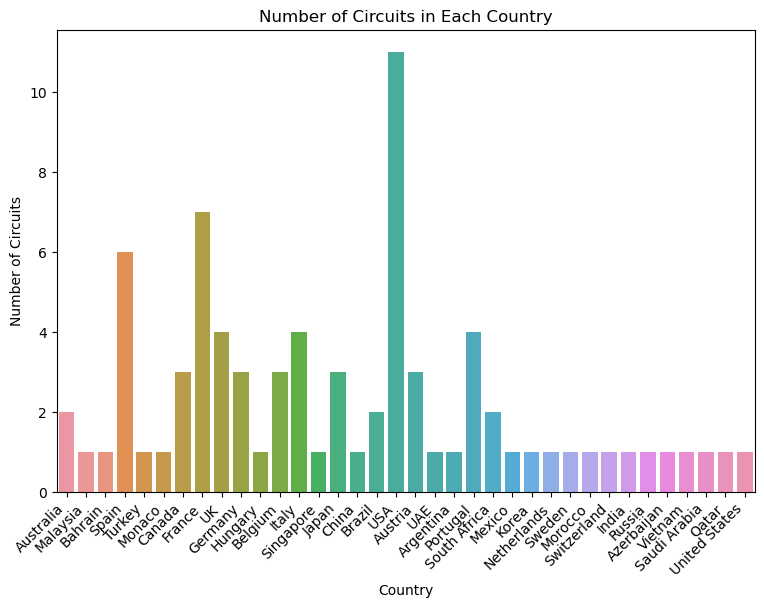

In [4]:
plt.figure(figsize=(9, 6))
sns.countplot(x='country', data=circuits_data)
plt.xlabel('Country')
plt.ylabel('Number of Circuits')
plt.title('Number of Circuits in Each Country')
plt.xticks(rotation=45, ha='right')
plt.show()

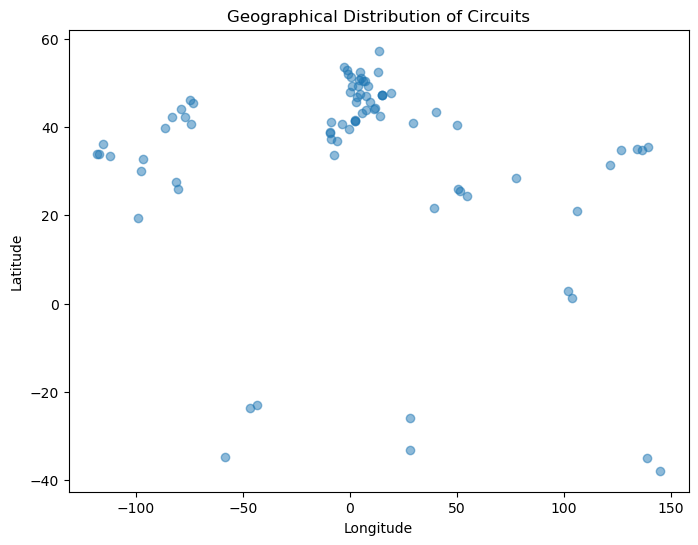

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(circuits_data['lng'], circuits_data['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Circuits')
plt.show()

### Constructor Results Dataset

In [6]:
print(constructor_results_data.info())
constructor_results_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11950 entries, 0 to 11949
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   constructorResultsId  11950 non-null  int64  
 1   raceId                11950 non-null  int64  
 2   constructorId         11950 non-null  int64  
 3   points                11950 non-null  float64
 4   status                11950 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 466.9+ KB
None


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N
3,4,18,4,5.0,\N
4,5,18,5,2.0,\N


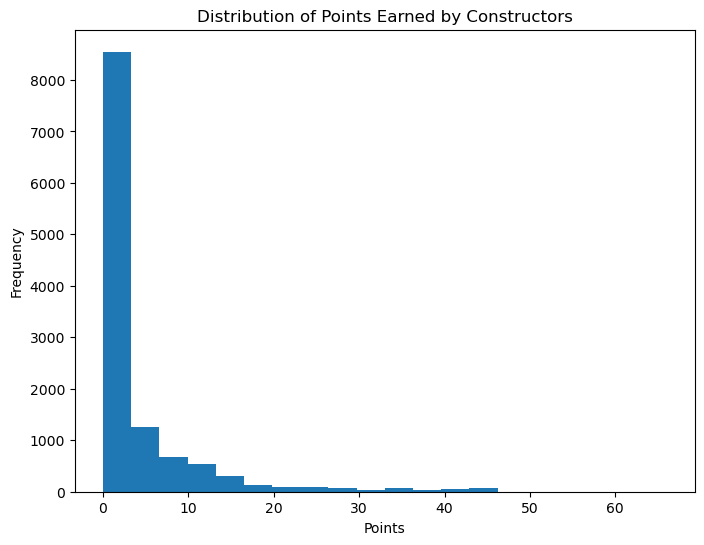

In [7]:
plt.figure(figsize=(8, 6))
plt.hist(constructor_results_data['points'], bins=20)
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.title('Distribution of Points Earned by Constructors')
plt.show()

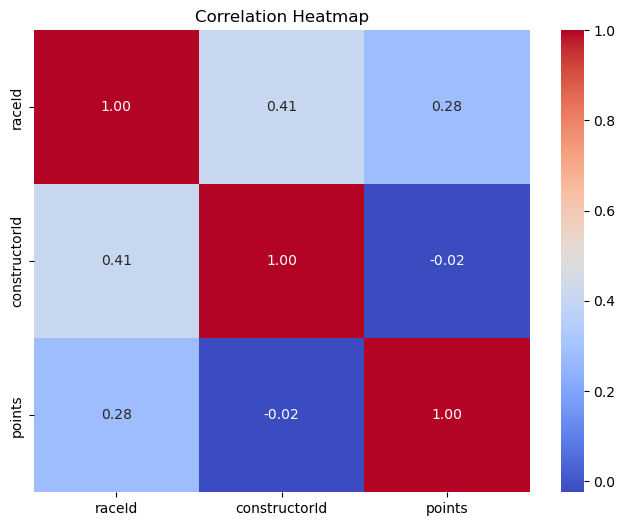

In [8]:
corr_matrix = constructor_results_data[['raceId', 'constructorId', 'points']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Constructor Standing Dataset

In [9]:
print(constructor_standing_data.info())
constructor_standing_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12716 entries, 0 to 12715
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   constructorStandingsId  12716 non-null  int64  
 1   raceId                  12716 non-null  int64  
 2   constructorId           12716 non-null  int64  
 3   points                  12716 non-null  float64
 4   position                12716 non-null  int64  
 5   positionText            12716 non-null  object 
 6   wins                    12716 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 695.5+ KB
None


,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1,1,1
1,2,18,2,8.0,3,3,0
2,3,18,3,9.0,2,2,0
3,4,18,4,5.0,4,4,0
4,5,18,5,2.0,5,5,0


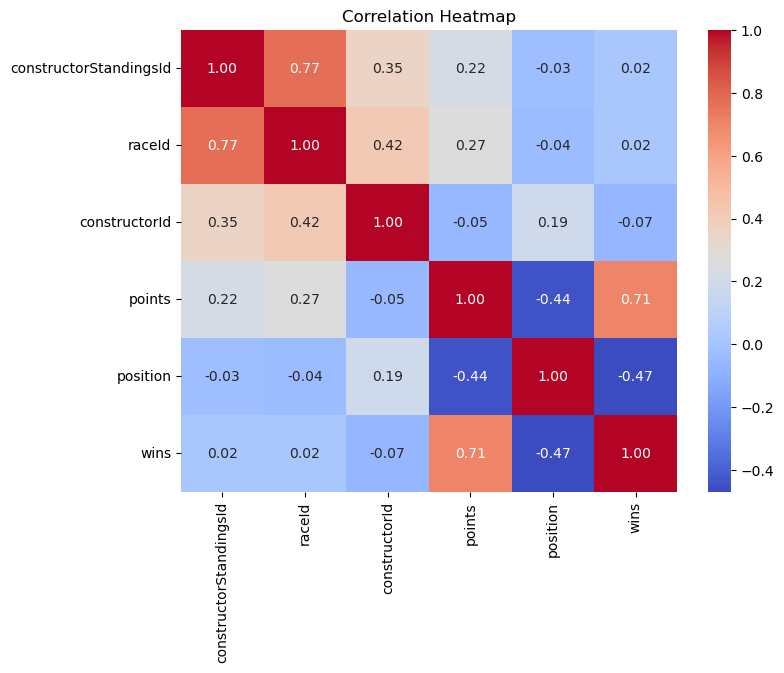

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(constructor_standing_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Constructors Dataset

In [11]:
print(constructors_data.info())
constructors_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   211 non-null    int64 
 1   constructorRef  211 non-null    object
 2   name            211 non-null    object
 3   nationality     211 non-null    object
 4   url             211 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.4+ KB
None


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


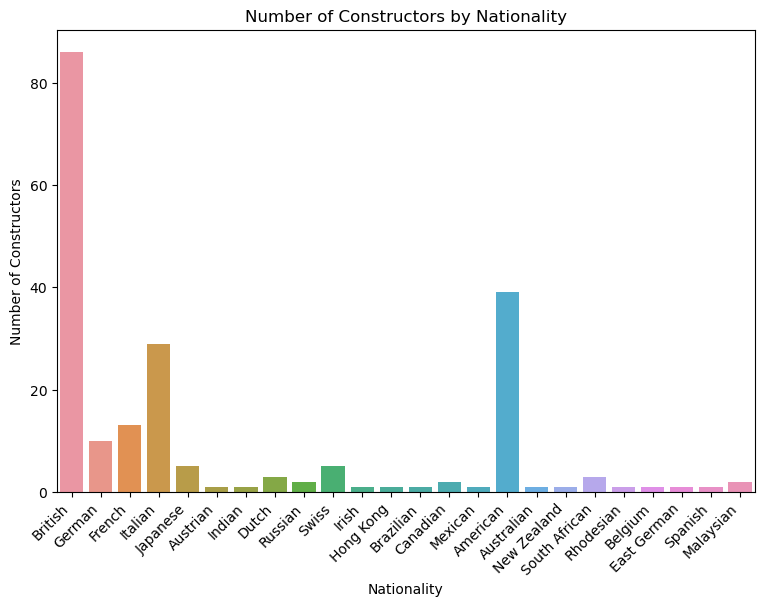

In [12]:
plt.figure(figsize=(9, 6))
sns.countplot(x='nationality', data=constructors_data)
plt.xlabel('Nationality')
plt.ylabel('Number of Constructors')
plt.title('Number of Constructors by Nationality')
plt.xticks(rotation=45, ha='right')
plt.show()

### Driver Standing Dataset

In [13]:
print(driver_standings_data.info())
driver_standings_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33394 entries, 0 to 33393
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   driverStandingsId  33394 non-null  int64 
 1   raceId             33394 non-null  int64 
 2   driverId           33394 non-null  int64 
 3   points             33389 non-null  object
 4   position           33394 non-null  int64 
 5   positionText       33394 non-null  object
 6   wins               33394 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.8+ MB
None


,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10,1,1,1
1,2,18,2,8,2,2,0
2,3,18,3,6,3,3,0
3,4,18,4,5,4,4,0
4,5,18,5,4,5,5,0


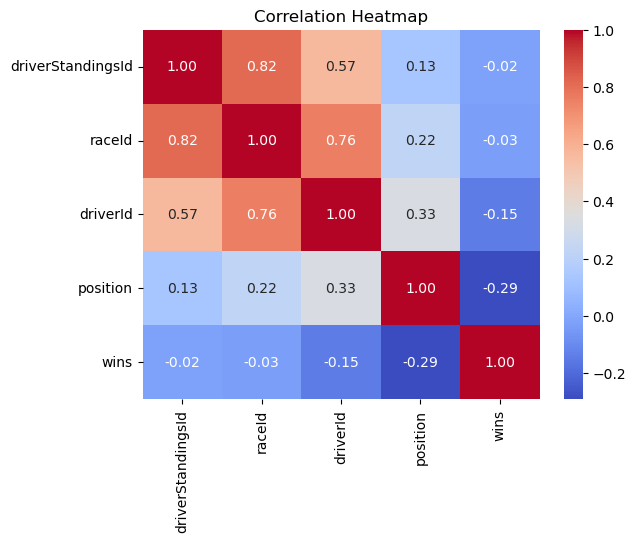

In [14]:
sns.heatmap(driver_standings_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Drivers Dataset

In [15]:
print(drivers_data.info())
drivers_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854 entries, 0 to 853
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     854 non-null    int64 
 1   driverRef    854 non-null    object
 2   number       854 non-null    object
 3   code         854 non-null    object
 4   forename     854 non-null    object
 5   surname      854 non-null    object
 6   dob          854 non-null    object
 7   nationality  854 non-null    object
 8   url          854 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.2+ KB
None


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


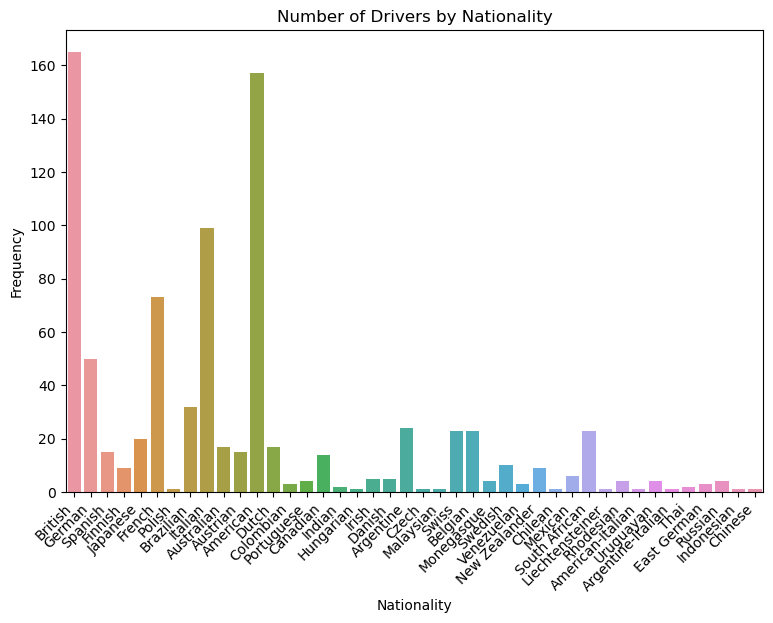

In [16]:
plt.figure(figsize=(9, 6))
sns.countplot(x='nationality', data=drivers_data)
plt.xlabel('Nationality')
plt.ylabel('Frequency')
plt.title('Number of Drivers by Nationality')
plt.xticks(rotation=45, ha='right')
plt.show()

### Lap Times Dataset

In [17]:
print(lap_times_data.info())
lap_times_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514592 entries, 0 to 514591
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   raceId        514592 non-null  int64 
 1   driverId      514592 non-null  int64 
 2   lap           514592 non-null  int64 
 3   position      514592 non-null  int64 
 4   time          514592 non-null  object
 5   milliseconds  514592 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ MB
None


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


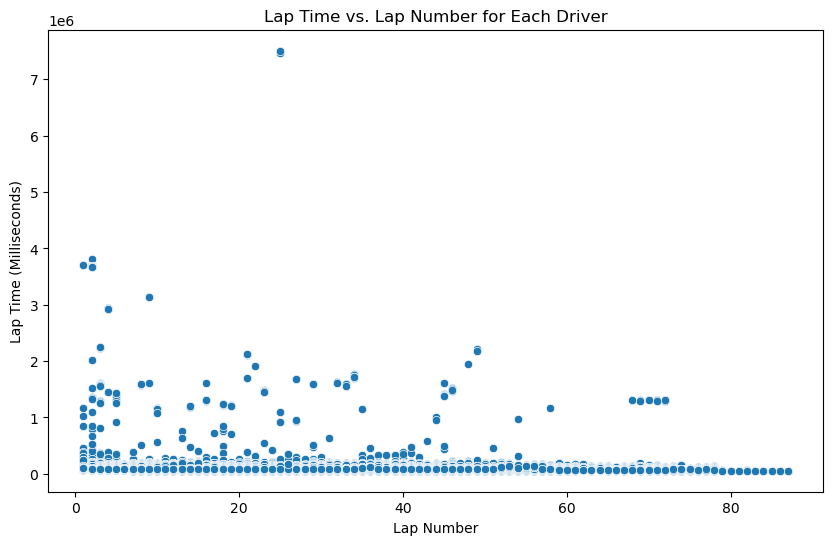

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='lap', y='milliseconds', data=lap_times_data)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (Milliseconds)')
plt.title('Lap Time vs. Lap Number for Each Driver')
plt.show()

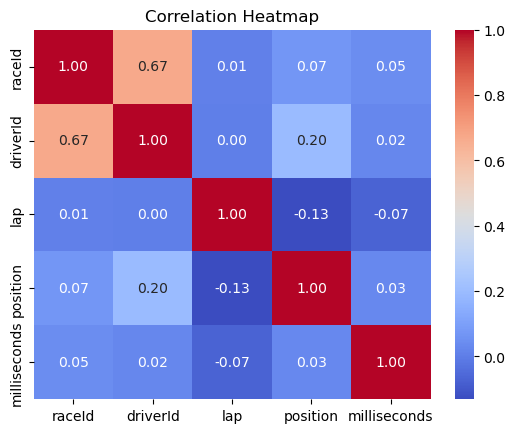

In [19]:
sns.heatmap(lap_times_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Pit Stops Dataset

In [20]:
print(pit_stops_data.info())
pit_stops_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8828 entries, 0 to 8827
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        8828 non-null   int64 
 1   driverId      8828 non-null   int64 
 2   stop          8828 non-null   int64 
 3   lap           8828 non-null   int64 
 4   time          8828 non-null   object
 5   duration      8828 non-null   object
 6   milliseconds  8828 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 482.9+ KB
None


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


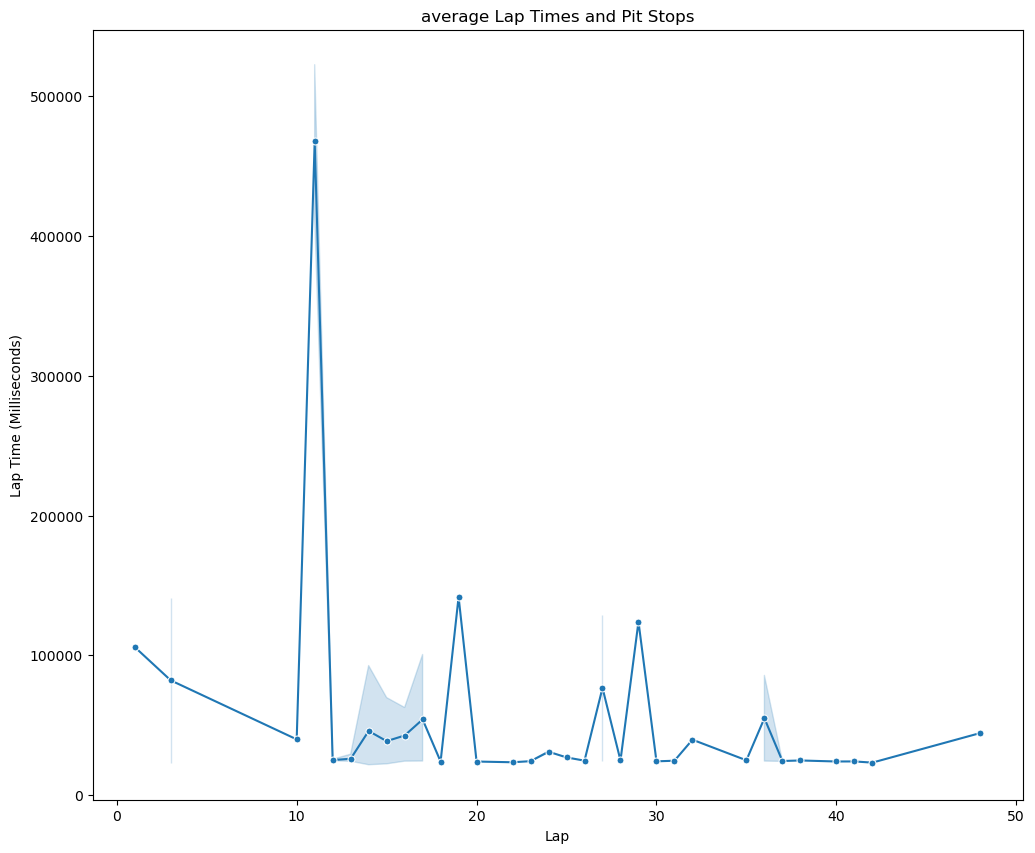

In [21]:
plt.figure(figsize=(12, 10))
sns.lineplot(x='lap', y=pit_stops_data.groupby(['lap'])['milliseconds'].mean(),data=pit_stops_data, marker='o', markersize=5)
plt.xlabel('Lap')
plt.ylabel('Lap Time (Milliseconds)')
plt.title('average Lap Times and Pit Stops')
plt.show()

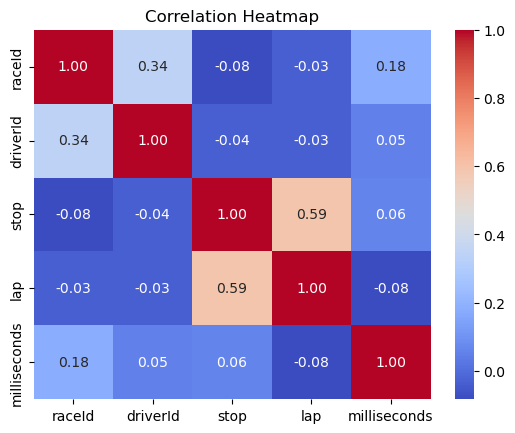

In [22]:
sns.heatmap(pit_stops_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Qualifying Dataset

In [23]:
print(qualifying_data.info())
qualifying_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9135 entries, 0 to 9134
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qualifyId      9135 non-null   int64 
 1   raceId         9135 non-null   int64 
 2   driverId       9135 non-null   int64 
 3   constructorId  9135 non-null   int64 
 4   number         9135 non-null   int64 
 5   position       9135 non-null   int64 
 6   q1             9127 non-null   object
 7   q2             9001 non-null   object
 8   q3             8880 non-null   object
dtypes: int64(6), object(3)
memory usage: 642.4+ KB
None


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


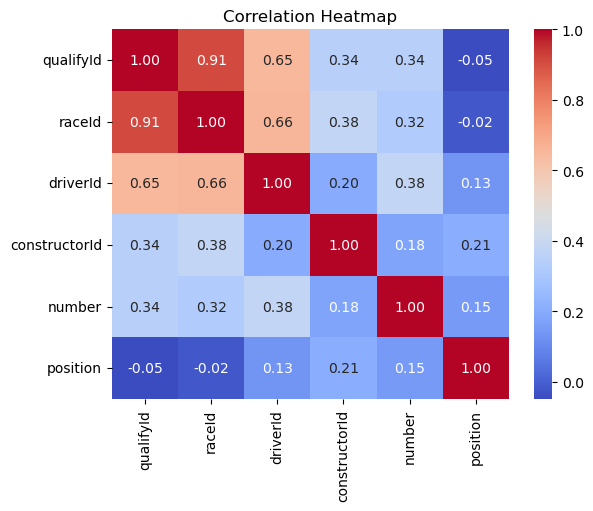

In [24]:
sns.heatmap(qualifying_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### races Dataset

In [25]:
print(races_data.info())
races_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   raceId     1080 non-null   int64 
 1   round      1080 non-null   int64 
 2   circuitId  1080 non-null   int64 
 3   name       1080 non-null   object
 4   date       1070 non-null   object
 5   time       1080 non-null   object
 6   url        1080 non-null   object
dtypes: int64(3), object(4)
memory usage: 59.2+ KB
None


,raceId,round,circuitId,name,date,time,url
0,1,1,1,Australian Grand Prix,3/29/2009,6:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
1,2,2,2,Malaysian Grand Prix,4/5/12009,9:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
2,3,3,17,Chinese Grand Prix,4/19/2009,7:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
3,4,4,3,Bahrain Grand Prix,4/26/2009,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
4,5,5,4,Spanish Grand Prix,5/10/2009,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


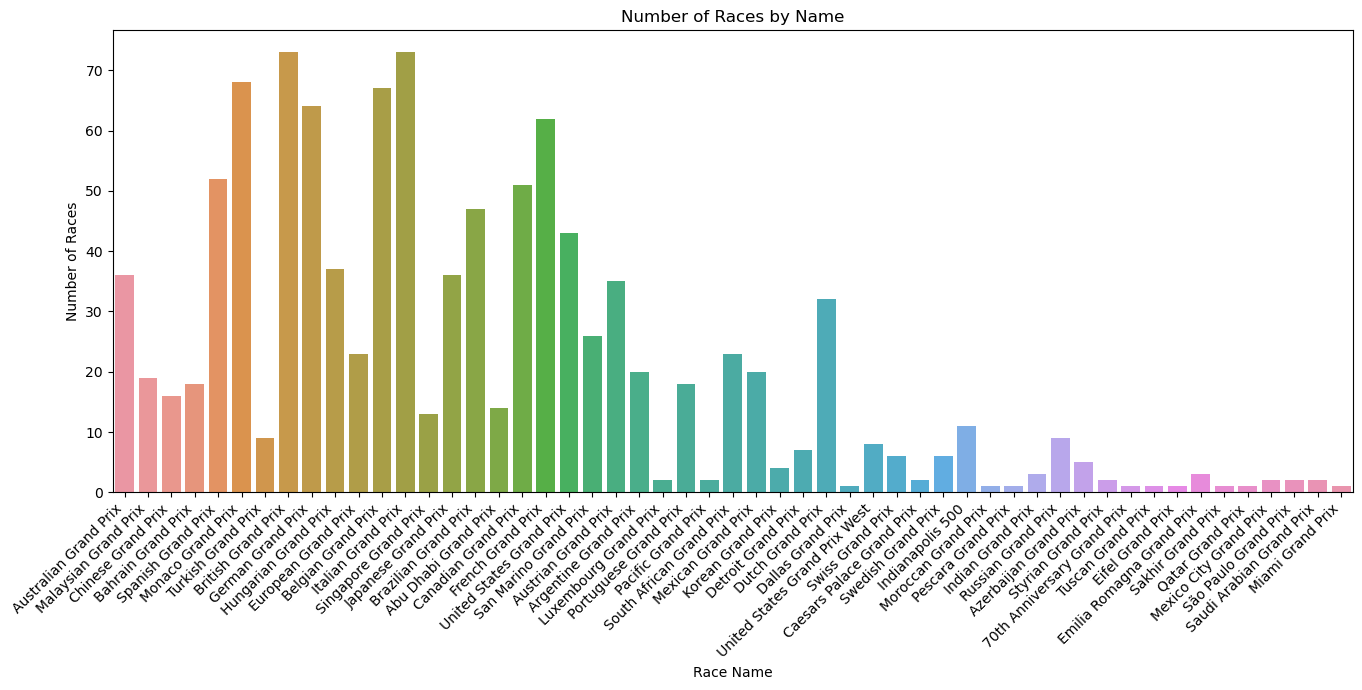

In [26]:
plt.figure(figsize=(16, 6))
sns.countplot(x='name', data=races_data)
plt.xlabel('Race Name')
plt.ylabel('Number of Races')
plt.title('Number of Races by Name')
plt.xticks(rotation=45, ha='right')
plt.show()

### Results Dataset

In [27]:
print(results_data.info())
results_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25399 entries, 0 to 25398
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         25399 non-null  int64  
 1   raceId           25399 non-null  int64  
 2   driverId         25399 non-null  int64  
 3   constructorId    25399 non-null  int64  
 4   number           25399 non-null  object 
 5   grid             25399 non-null  int64  
 6   position         25399 non-null  object 
 7   positionText     25399 non-null  object 
 8   positionOrder    25399 non-null  int64  
 9   points           25399 non-null  float64
 10  laps             25399 non-null  int64  
 11  time             25399 non-null  object 
 12  milliseconds     25399 non-null  object 
 13  fastestLap       25399 non-null  object 
 14  rank             25399 non-null  object 
 15  fastestLapTime   25399 non-null  object 
 16  fastestLapSpeed  25399 non-null  object 
 17  statusId    

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,34:50.6,5690616,39,2,01:27.5,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,5.478,5696094,41,3,01:27.7,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,8.163,5698779,41,5,01:28.1,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,17.181,5707797,58,7,01:28.6,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,18.014,5708630,43,1,01:27.4,218.385,1


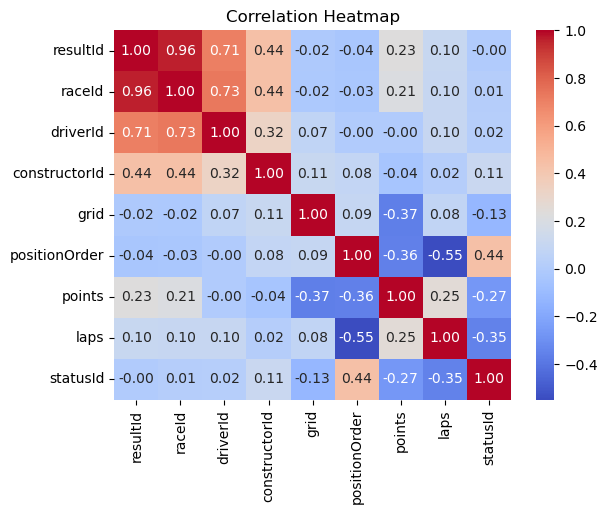

In [28]:
sns.heatmap(results_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

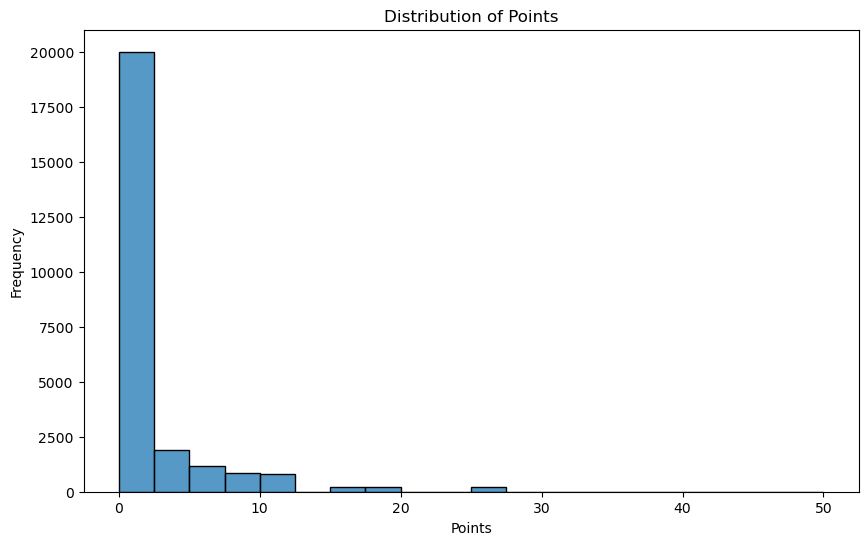

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=results_data, x='points', bins=20)
plt.title('Distribution of Points')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.show()

### Seasons Dataset

In [30]:
print(seasons_data.info())
seasons_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    73 non-null     int64 
 1   url     73 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.3+ KB
None


,year,url
0,2009,https://en.wikipedia.org/wiki/2009_Formula_One...
1,2008,https://en.wikipedia.org/wiki/2008_Formula_One...
2,2007,https://en.wikipedia.org/wiki/2007_Formula_One...
3,2006,https://en.wikipedia.org/wiki/2006_Formula_One...
4,2005,https://en.wikipedia.org/wiki/2005_Formula_One...


### Status Dataset

In [31]:
print(status_data.info())
status_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   statusId  137 non-null    int64 
 1   status    137 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.3+ KB
None


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## Step 2: Data Wrangling on multiple tables <a id="part1.2"></a>

In [32]:
circuits_subset = circuits_data[['circuitId','country','name','alt']]
circuits_subset = circuits_subset.rename(columns={'name':'circuitName'})

constructors_subset = constructors_data[['constructorId','name']]
constructors_subset = constructors_subset.rename(columns={'name':'constructorName'})

driver_standings_subset = driver_standings_data[['raceId','driverId','wins']]

drivers_subset = drivers_data[['driverId','forename','surname','dob']]

races_subset = races_data[['raceId','circuitId','name','date']]
races_subset = races_subset.rename(columns={'name':'raceName'})

results_subset = results_data[['raceId','driverId','constructorId','grid','positionOrder','fastestLapTime','fastestLapSpeed','laps']]

In [33]:
merged_data = (
    results_subset
    .merge(driver_standings_subset, on=['raceId', 'driverId'],how='inner')
    .merge(drivers_subset, on='driverId',how='inner')
    .merge(races_subset, on='raceId',how='inner')
    .merge(circuits_subset, on='circuitId',how='inner')
    .merge(constructors_subset, on='constructorId',how='inner')
)

In [34]:
print(merged_data.info())
merged_data.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24918 entries, 0 to 24917
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   raceId           24918 non-null  int64 
 1   driverId         24918 non-null  int64 
 2   constructorId    24918 non-null  int64 
 3   grid             24918 non-null  int64 
 4   positionOrder    24918 non-null  int64 
 5   fastestLapTime   24918 non-null  object
 6   fastestLapSpeed  24918 non-null  object
 7   laps             24918 non-null  int64 
 8   wins             24918 non-null  int64 
 9   forename         24918 non-null  object
 10  surname          24918 non-null  object
 11  dob              24918 non-null  object
 12  circuitId        24918 non-null  int64 
 13  raceName         24918 non-null  object
 14  date             24712 non-null  object
 15  country          24918 non-null  object
 16  circuitName      24918 non-null  object
 17  alt              24918 non-null

,raceId,driverId,constructorId,grid,positionOrder,fastestLapTime,fastestLapSpeed,laps,wins,forename,surname,dob,circuitId,raceName,date,country,circuitName,alt,constructorName
0,18,1,1,1,1,01:27.5,218.3,58,1,Lewis,Hamilton,1985-01-07,1,Australian Grand Prix,3/16/2008,Australia,Albert Park Grand Prix Circuit,10,McLaren
1,18,5,1,3,5,01:27.4,218.385,58,0,Heikki,Kovalainen,1981-10-19,1,Australian Grand Prix,3/16/2008,Australia,Albert Park Grand Prix Circuit,10,McLaren
2,36,1,1,4,3,01:26.4,221.083,58,0,Lewis,Hamilton,1985-01-07,1,Australian Grand Prix,3/18/2007,Australia,Albert Park Grand Prix Circuit,10,McLaren
3,36,4,1,2,2,01:26.3,221.178,58,0,Fernando,Alonso,1981-07-29,1,Australian Grand Prix,3/18/2007,Australia,Albert Park Grand Prix Circuit,10,McLaren
4,338,1,1,11,6,01:28.5,215.7,58,0,Lewis,Hamilton,1985-01-07,1,Australian Grand Prix,3/28/2010,Australia,Albert Park Grand Prix Circuit,10,McLaren


## Step 3: Data Cleansing and Transformation <a id="part1.3"></a>

### Naming inconsistencies

In [35]:
merged_data['country'].replace('United States','USA', inplace = True)

In [36]:
merged_data['date'] = merged_data['date'].replace({
    "12009": "2009",
    "12015": "2015",
    "12017": "2017",
    "12018": "2018",
    "12020": "2020",
    "12011": "2021",
    "12005": "2005",
    "12021": "2021"
}, regex=True)

In [37]:
merged_data = merged_data.replace({r"\N": float("nan")})

### formatting data types

In [38]:
def time_to_milliseconds(time_str):
    if pd.isna(time_str) or isinstance(time_str, float):
        return np.nan  
    else:
        time_parts = time_str.split(':')
        minutes = int(time_parts[0])
        seconds, milliseconds = map(int, time_parts[1].split('.'))
        total_milliseconds = (minutes * 60 + seconds) * 1000 + milliseconds
        return total_milliseconds


merged_data = merged_data.loc[merged_data['fastestLapTime'] != '192.074']
merged_data = merged_data.reset_index(drop=True)
merged_data['fastestLapTime'] = merged_data['fastestLapTime'].apply(time_to_milliseconds)  

In [39]:
merged_data['fastestLapSpeed'] = merged_data['fastestLapSpeed'].astype('float')

merged_data['date'] = pd.to_datetime(merged_data['date'])

merged_data['dob'] = pd.to_datetime(merged_data['dob'])

merged_data['alt'] = merged_data['alt'].astype('float')

### Filling null values

In [40]:
merged_data.isnull().sum()

raceId                 0
driverId               0
constructorId          0
grid                   0
positionOrder          0
fastestLapTime     18024
fastestLapSpeed    18024
laps                   0
wins                   0
forename               0
surname                0
dob                    0
circuitId              0
raceName               0
date                 205
country                0
circuitName            0
alt                   20
constructorName        0
dtype: int64

In [41]:
merged_data = merged_data.sort_values(by='date')

# Interpolate missing dates in the 'date' column using forward fill (pad)
merged_data['date'] = merged_data['date'].fillna(method='pad')

In [42]:
country_alt = merged_data.groupby('country')['alt'].mean().to_dict()

# Calculate the overall average altitude for all countries in the training data
general_avg = merged_data['alt'].mean()

# Define the lambda function for filling missing values in the 'alt' column
def fill_alt(row):
    country = row['country']
    if pd.notna(row['alt']):
        return row['alt']
    elif country in country_alt and pd.notna(country_alt[country]):
        return country_alt[country]
    else:
        return general_avg

# Apply the lambda function to fill missing values in the 'alt' column
merged_data['alt'] = merged_data.apply(fill_alt, axis=1)

In [43]:
median_race_fastlaptime = merged_data.groupby('raceId')['fastestLapTime'].median().to_dict()

# Calculate the overall average altitude for all countries in the training data
general_median_fastlaptime = merged_data['fastestLapTime'].median()

# Define the lambda function for filling missing values in the 'alt' column
def fill_fastlaptime(row):
    raceId = row['raceId']
    if pd.notna(row['fastestLapTime']):
        return row['fastestLapTime']
    elif raceId in median_race_fastlaptime and pd.notna(median_race_fastlaptime[raceId]):
        return median_race_fastlaptime[raceId]
    else:
        return general_median_fastlaptime

# Apply the lambda function to fill missing values in the 'alt' column
merged_data['fastestLapTime'] = merged_data.apply(fill_fastlaptime, axis=1)

In [44]:
median_race_fastlapSpeed = merged_data.groupby('raceId')['fastestLapSpeed'].median().to_dict()

# Calculate the overall average altitude for all countries in the training data
general_median_fastlapSpeed = merged_data['fastestLapSpeed'].median()

# Define the lambda function for filling missing values in the 'alt' column
def fill_fastlapspeed(row):
    raceId = row['raceId']
    if pd.notna(row['fastestLapSpeed']):
        return row['fastestLapSpeed']
    elif raceId in median_race_fastlapSpeed and pd.notna(median_race_fastlapSpeed[raceId]):
        return median_race_fastlapSpeed[raceId]
    else:
        return general_median_fastlapSpeed

# Apply the lambda function to fill missing values in the 'alt' column
merged_data['fastestLapSpeed'] = merged_data.apply(fill_fastlapspeed, axis=1)

In [45]:
merged_data.isnull().sum()

raceId             0
driverId           0
constructorId      0
grid               0
positionOrder      0
fastestLapTime     0
fastestLapSpeed    0
laps               0
wins               0
forename           0
surname            0
dob                0
circuitId          0
raceName           0
date               0
country            0
circuitName        0
alt                0
constructorName    0
dtype: int64

### New features

In [46]:
merged_data['top10'] = merged_data['positionOrder'].apply(lambda x: 1 if int(x) <= 10 else 0)

In [47]:
merged_data['fullName'] = merged_data['forename'] + ' ' + merged_data['surname']

merged_data['year'] = merged_data['date'].dt.year

merged_data['month'] = merged_data['date'].dt.month

merged_data['age'] = (merged_data['date'].dt.year - merged_data['dob'].dt.year) - \
                 ((merged_data['date'].dt.month < merged_data['dob'].dt.month) |
                  ((merged_data['date'].dt.month == merged_data['dob'].dt.month) & (merged_data['date'].dt.day < merged_data['dob'].dt.day)))


### Text pre-processing

In [48]:
object_columns = merged_data.select_dtypes(include=['object']).columns

# Apply the lowercase transformation to each cell in object columns
merged_data[object_columns] = merged_data[object_columns].applymap(lambda x: x.lower() if isinstance(x, str) else x)

In [49]:
for column in object_columns:
    merged_data[column] = merged_data[column].replace('', '', regex=False)

### Check for duplicates

In [50]:
# Find duplicate rows
duplicate_rows = merged_data[merged_data.duplicated()]

# Display the duplicate rows
print(duplicate_rows)

Empty DataFrame
Columns: [raceId, driverId, constructorId, grid, positionOrder, fastestLapTime, fastestLapSpeed, laps, wins, forename, surname, dob, circuitId, raceName, date, country, circuitName, alt, constructorName, top10, fullName, year, month, age]
Index: []

[0 rows x 24 columns]


### drop columns

In [51]:
merged_data.drop(columns=['raceId','driverId','constructorId','positionOrder','circuitId','date','dob','forename','surname'], inplace=True)

### Handling Outliers

In [52]:
def diagnostic_plots(df, variable):
    plt.figure(figsize=(18, 8))
    
    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], kde=True)
    plt.title('Histogram')
    
    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('RM quantiles')
    
    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')
    
    plt.show()

grid


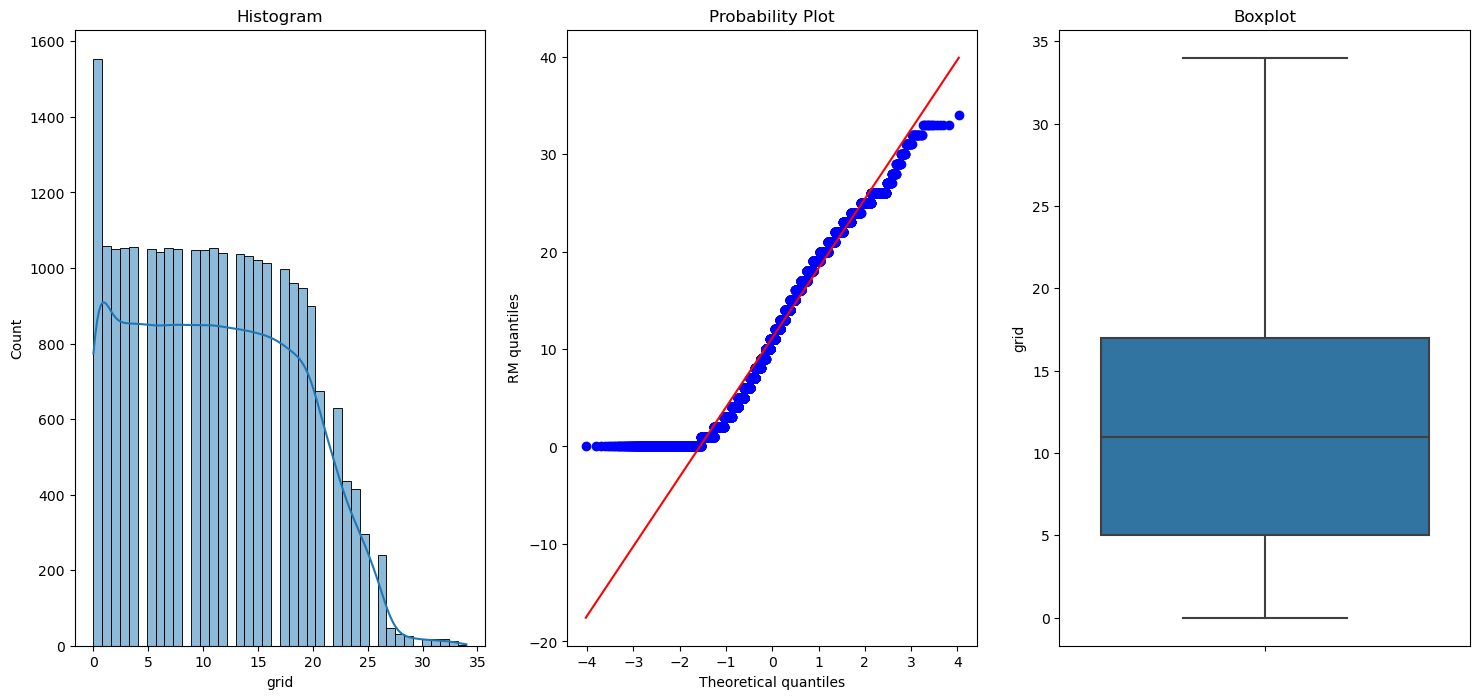

fastestLapTime


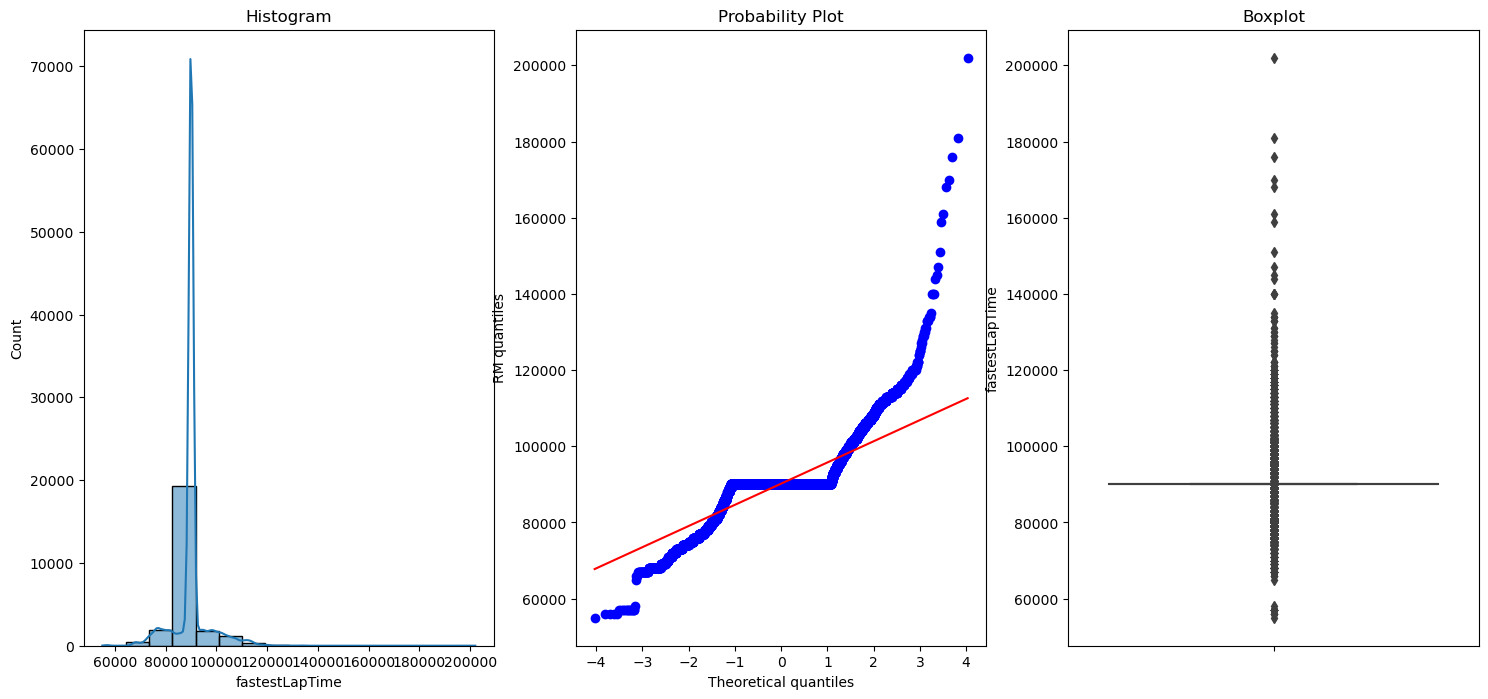

fastestLapSpeed


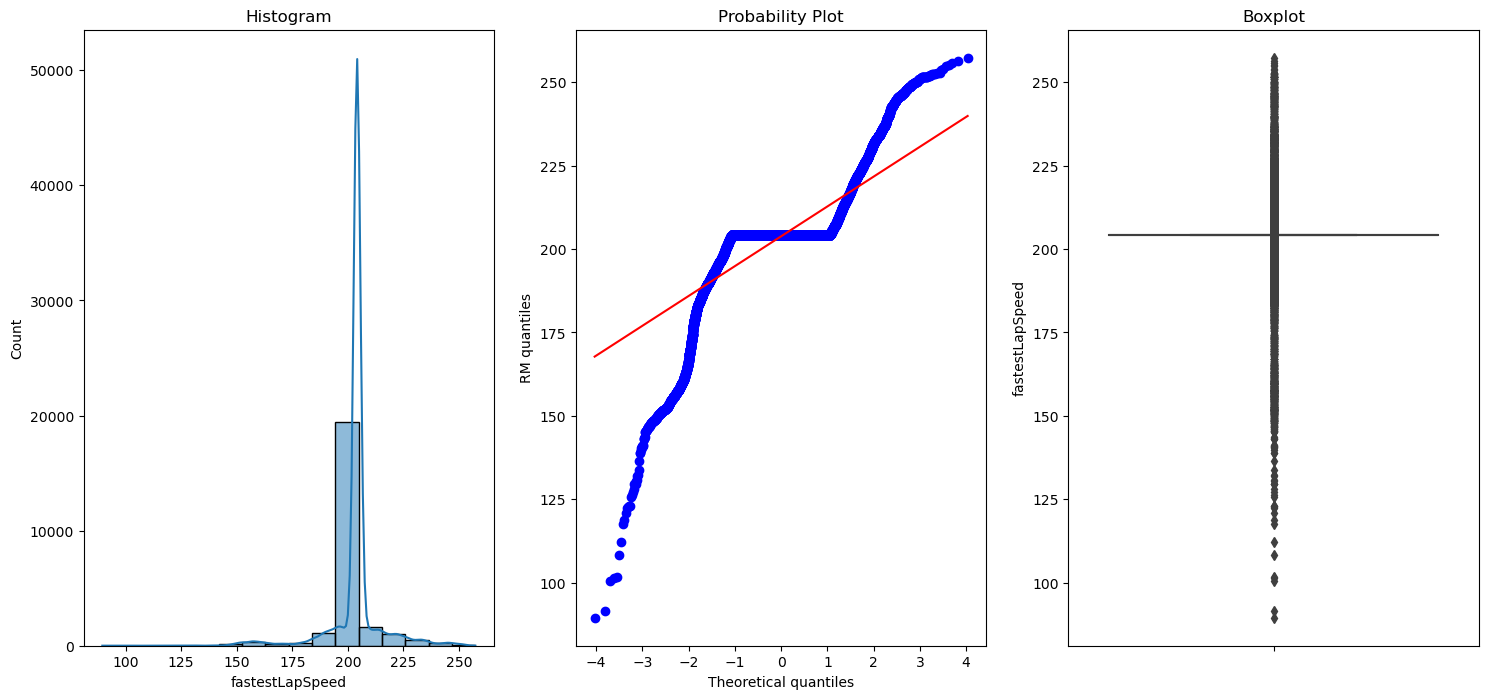

laps


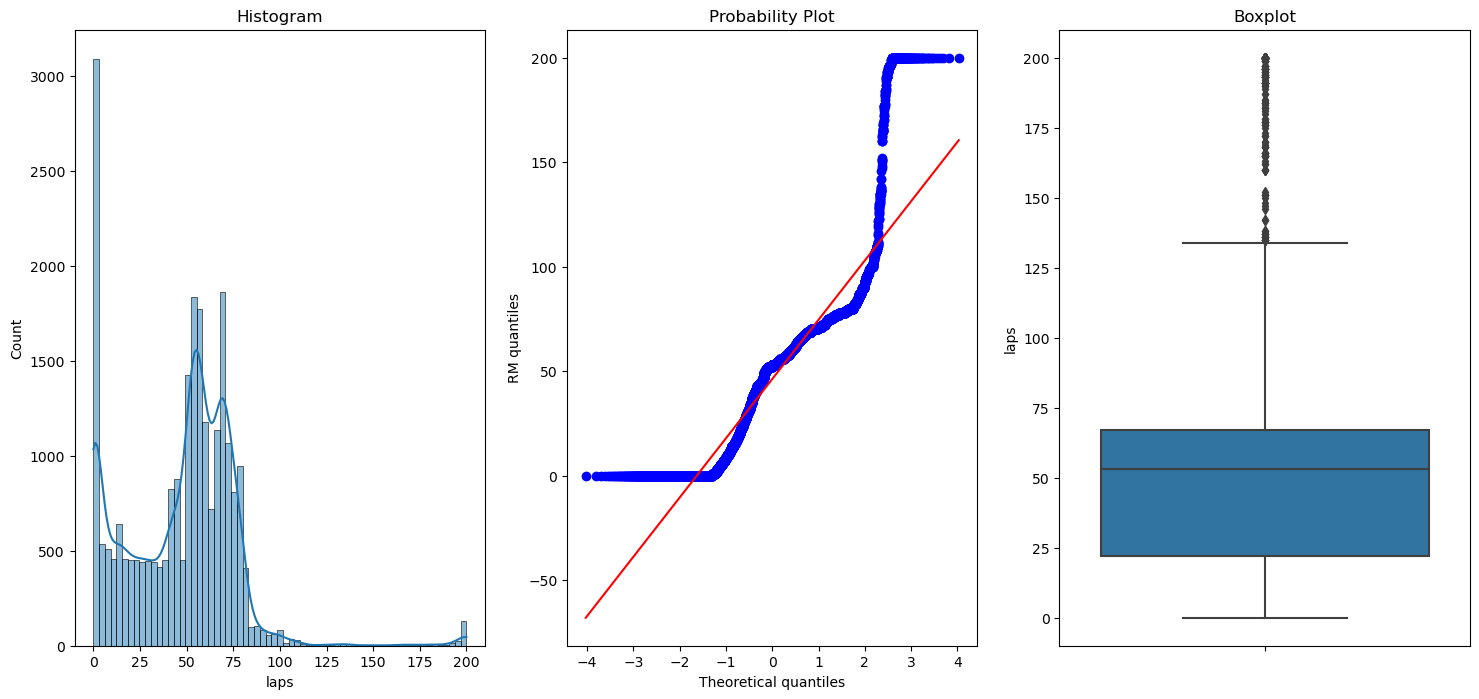

wins


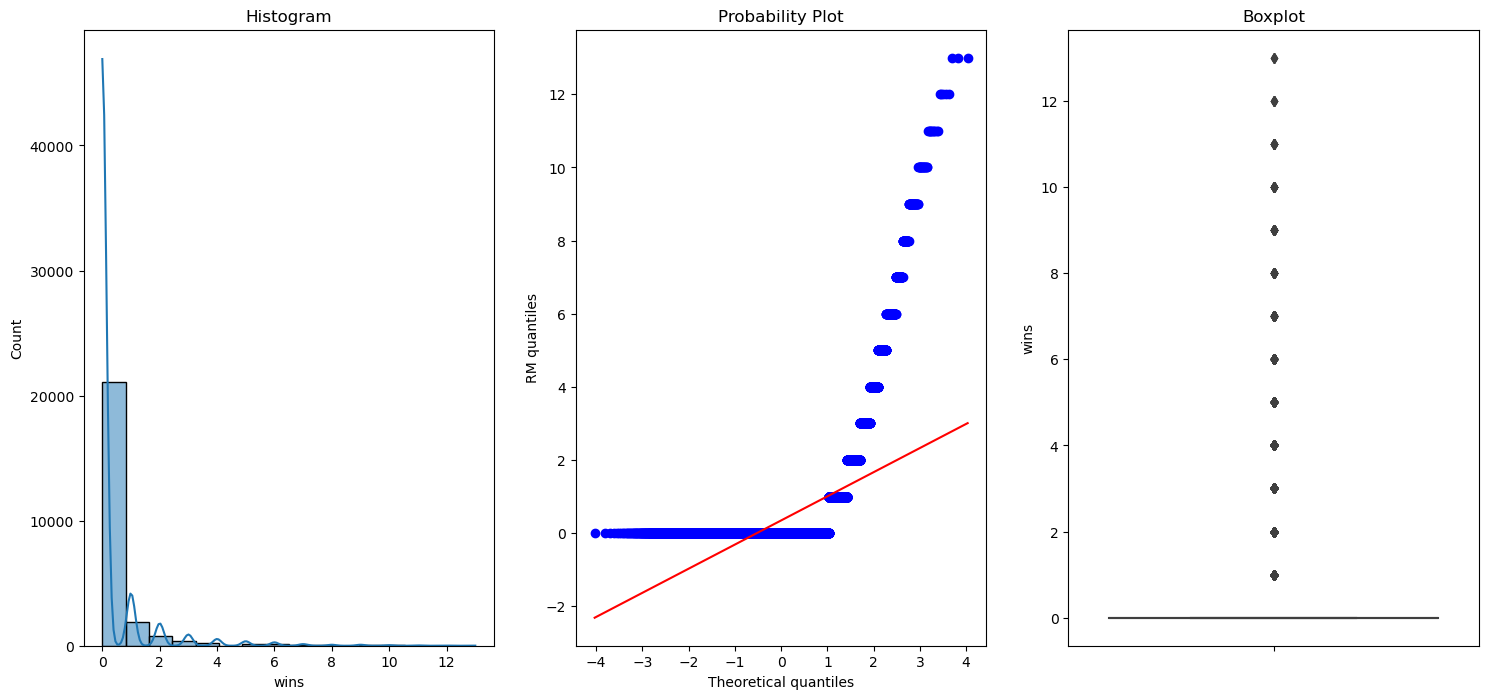

alt


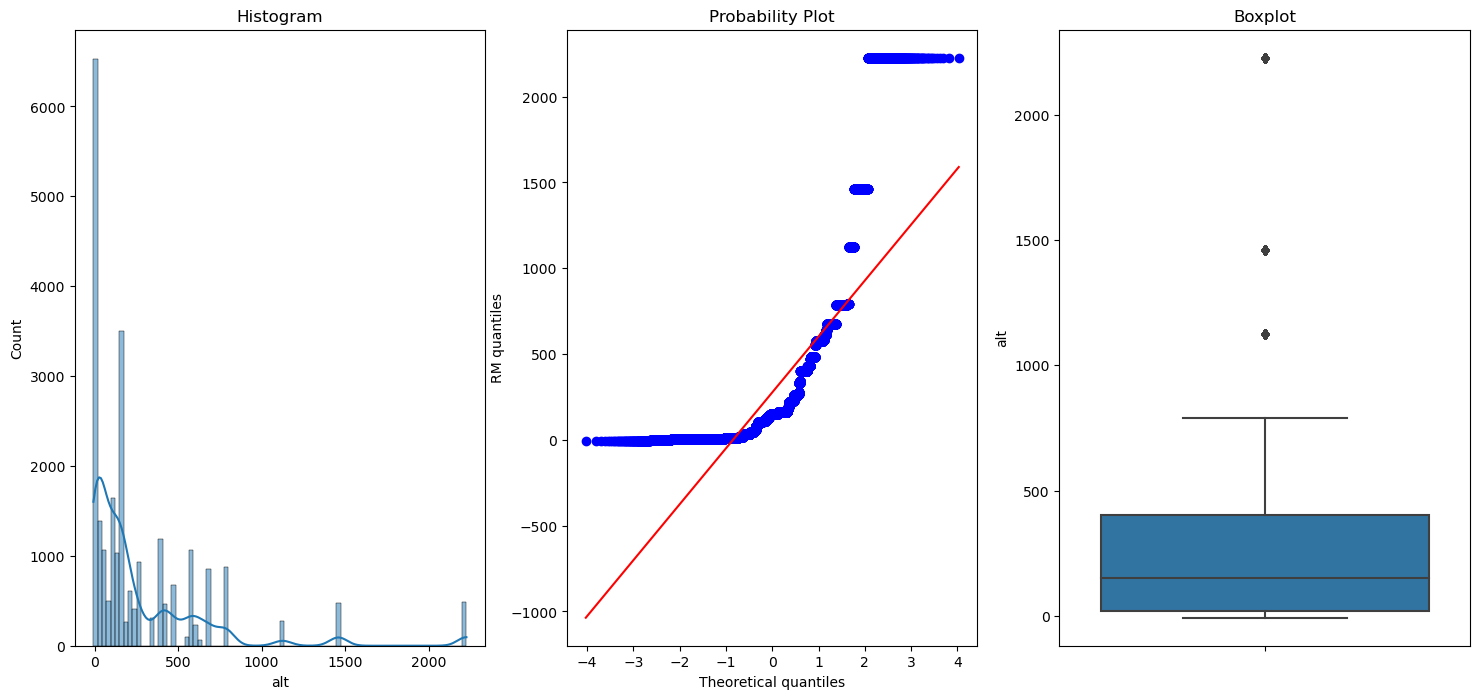

top10


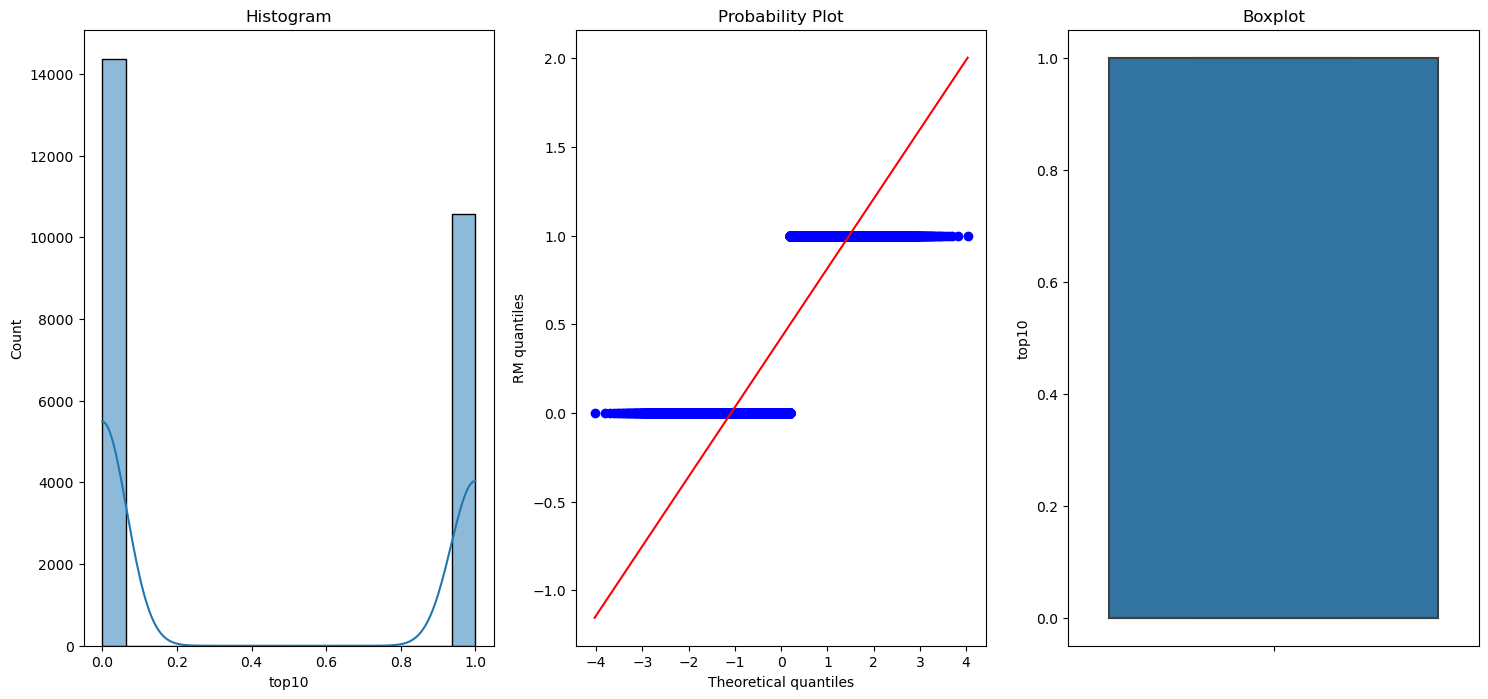

year


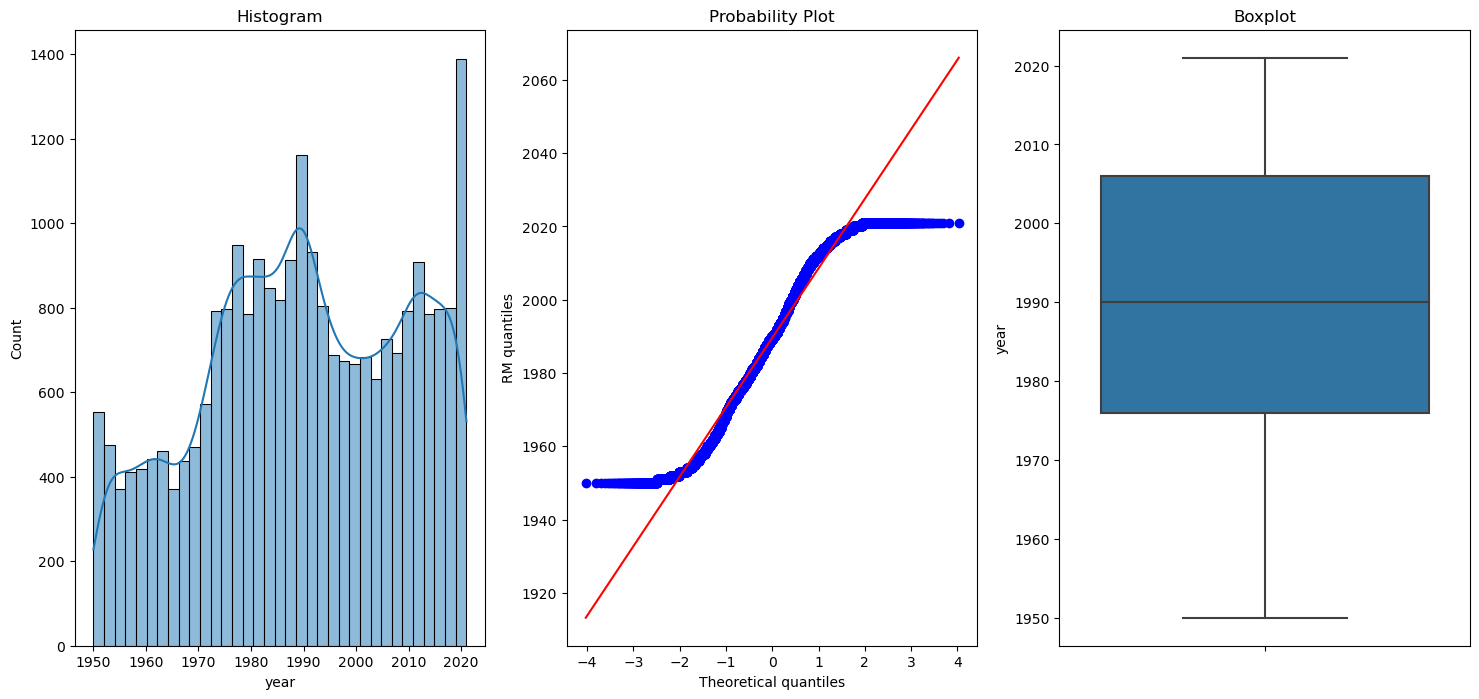

month


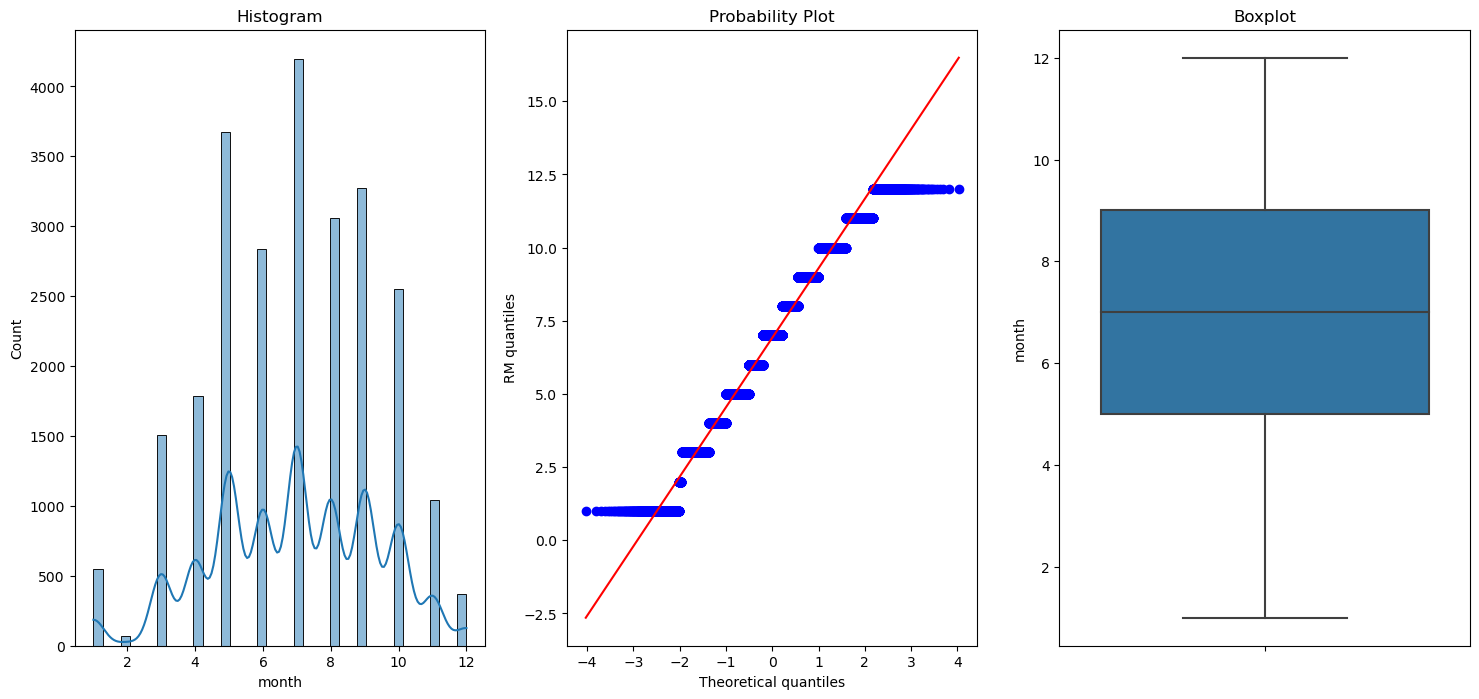

age


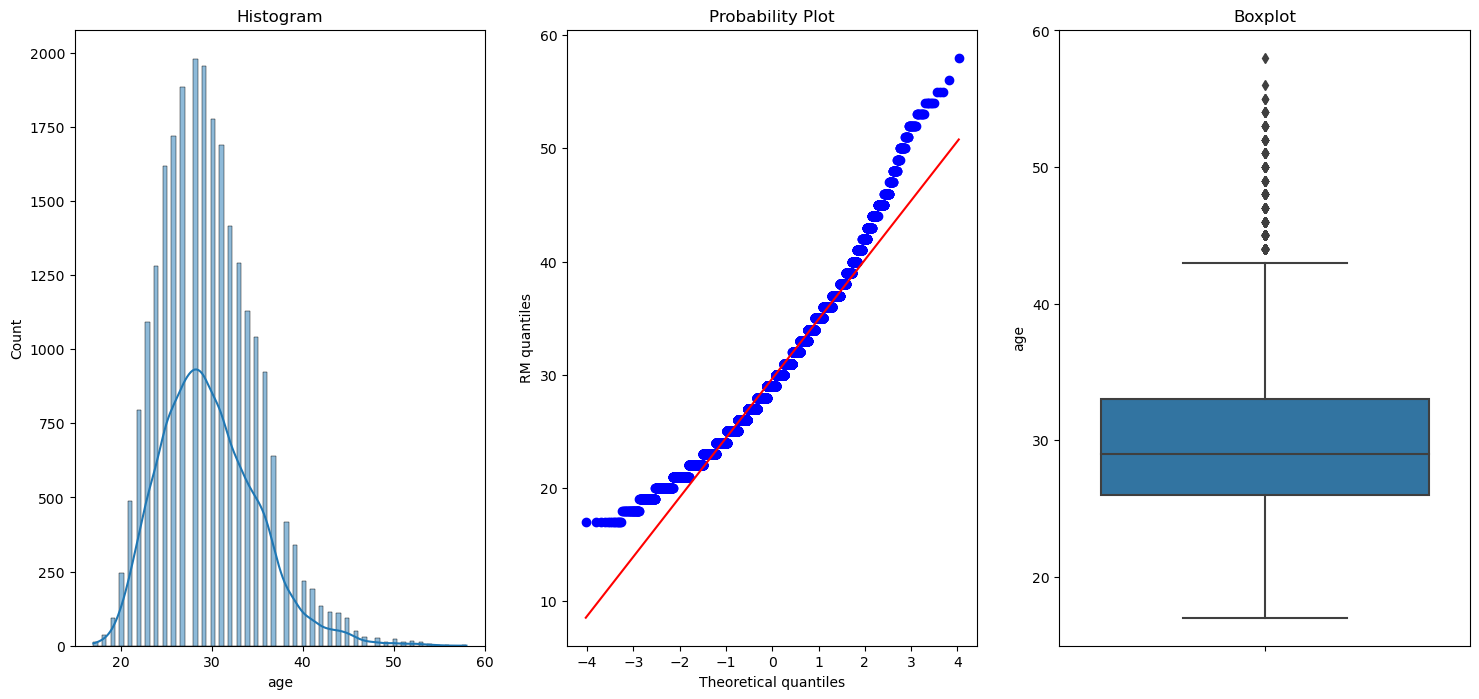

In [53]:
numerical_columns = merged_data.select_dtypes(include=['number']).columns

for column in numerical_columns:
    print(column)
    diagnostic_plots(merged_data, column)

In [54]:
import scipy.stats as stats
from feature_engine.outliers import Winsorizer

In [55]:
windsorizer = Winsorizer(capping_method ='quantiles', 
                        tail='both', # cap left, right or both tails
                        fold =0.05,
                        variables=['fastestLapTime','fastestLapSpeed','laps','wins','alt','age'])

windsorizer.fit(merged_data)

Winsorizer(capping_method='quantiles', fold=0.05, tail='both',
           variables=['fastestLapTime', 'fastestLapSpeed', 'laps', 'wins',
                      'alt', 'age'])

In [56]:
merged_data = windsorizer.transform(merged_data)

### Capping

In [57]:
# windsorizer = Winsorizer(capping_method='gaussian', 
#                           tail='both',
#                           fold=3,
#                           variables=['fastestLapTime','fastestLapSpeed','laps','wins','age'])

# windsorizer.fit(merged_data)

In [58]:
# merged_data = windsorizer.transform(merged_data)

### Numerical Transformation

### YeoJohnson Transformer

In [59]:
from feature_engine.transformation import YeoJohnsonTransformer

In [60]:
yjt = YeoJohnsonTransformer(variables=['fastestLapTime','fastestLapSpeed','laps','alt','age'])

yjt.fit(merged_data)

YeoJohnsonTransformer(variables=['fastestLapTime', 'fastestLapSpeed', 'laps',
                                 'alt', 'age'])

In [61]:
merged_data = yjt.transform(merged_data)

### Power Transformer

In [62]:
# from feature_engine.transformation import PowerTransformer

In [63]:
# et = PowerTransformer(variables = ['fastestLapTime','fastestLapSpeed','laps','age'], exp=0.3)

# # fit transformer to data
# et.fit(merged_data)

In [64]:
# merged_data = et.transform(merged_data)

### Train test split

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    merged_data.drop('top10', axis=1), merged_data['top10'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((17441, 14), (7476, 14))

In [67]:
print(X_train.info())
X_train.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17441 entries, 2306 to 23236
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   grid             17441 non-null  int64  
 1   fastestLapTime   17441 non-null  float64
 2   fastestLapSpeed  17441 non-null  float64
 3   laps             17441 non-null  float64
 4   wins             17441 non-null  int64  
 5   raceName         17441 non-null  object 
 6   country          17441 non-null  object 
 7   circuitName      17441 non-null  object 
 8   alt              17441 non-null  float64
 9   constructorName  17441 non-null  object 
 10  fullName         17441 non-null  object 
 11  year             17441 non-null  int64  
 12  month            17441 non-null  int64  
 13  age              17441 non-null  float64
dtypes: float64(5), int64(4), object(5)
memory usage: 2.0+ MB
None


,grid,fastestLapTime,fastestLapSpeed,laps,wins,raceName,country,circuitName,alt,constructorName,fullName,year,month,age
2306,7,3010.497298,3.686406,32.099903,1,british grand prix,uk,silverstone circuit,7.866782,williams,pastor maldonado,2012,7,2.862137
2964,17,3132.424246,3.636972,34.248837,0,korean grand prix,korea,korean international circuit,2.295984,williams,valtteri bottas,2013,10,2.778761
5790,6,2864.896988,3.658330,45.686300,1,italian grand prix,italy,autodromo nazionale di monza,7.998183,ferrari,piero taruffi,1952,9,3.118837
4560,8,3092.109635,3.634090,34.782276,0,chinese grand prix,china,shanghai international circuit,2.295984,toro rosso,carlos sainz,2016,4,2.716850
5095,6,2605.862804,3.658264,42.109445,0,canadian grand prix,canada,circuit gilles villeneuve,3.309720,ferrari,kimi räikkönen,2016,6,3.063459


### Encoding and Discretion

### One Hot Encoding

In [68]:
from feature_engine.encoding import OneHotEncoder

In [69]:
ohe_enc = OneHotEncoder(
    
    # to indicate how many top categories
    top_categories=5,  
    
    # we can select which variables to encode
    variables=['raceName','circuitName','constructorName','fullName','country'],
    
    # to indicate if we drop one of the binaries
    drop_last=False)

ohe_enc.fit(X_train)

OneHotEncoder(top_categories=5,
              variables=['raceName', 'circuitName', 'constructorName',
                         'fullName', 'country'])

In [70]:
ohe_enc.encoder_dict_

{'raceName': ['british grand prix',
  'italian grand prix',
  'monaco grand prix',
  'german grand prix',
  'belgian grand prix'],
 'circuitName': ['autodromo nazionale di monza',
  'circuit de monaco',
  'silverstone circuit',
  'circuit de spa-francorchamps',
  'circuit gilles villeneuve'],
 'constructorName': ['ferrari',
  'mclaren',
  'williams',
  'team lotus',
  'tyrrell'],
 'fullName': ['kimi räikkönen',
  'fernando alonso',
  'jenson button',
  'rubens barrichello',
  'sebastian vettel'],
 'country': ['italy', 'uk', 'usa', 'germany', 'monaco']}

In [71]:
X_train = ohe_enc.transform(X_train)
X_test = ohe_enc.transform(X_test)

### Ordinal Encoding

In [72]:
# from feature_engine.encoding import OrdinalEncoder

In [73]:
# ordinal_enc = OrdinalEncoder(
#     encoding_method='arbitrary',
#     variables=['raceName','circuitName'])

In [74]:
# ordinal_enc.fit(X_train)

In [75]:
# ordinal_enc.encoder_dict_

In [76]:
# X_train = ordinal_enc.transform(X_train)
# X_test = ordinal_enc.transform(X_test)

### Count Frequency

In [77]:
# from feature_engine.encoding import CountFrequencyEncoder

In [78]:
# count_enc = CountFrequencyEncoder(
#     encoding_method='frequency', # to do frequency ==> encoding_method='frequency'
#     variables=['fullName'])

In [79]:
# count_enc.fit(X_train)

In [80]:
# count_enc.encoder_dict_

In [81]:
# X_train = count_enc.transform(X_train)
# X_test = count_enc.transform(X_test

# C:\Users\amelia\anaconda3\lib\site-packages\feature_engine\encoding\base_encoder.py:257: UserWarning: During the encoding, NaN values were introduced in the feature(s) fullName.
#   warnings.warn(

### Equal Width Discretion

In [82]:
from feature_engine.discretisation import EqualWidthDiscretiser

In [83]:
disc = EqualWidthDiscretiser(bins=10, variables = ['grid', 'fastestLapTime','fastestLapSpeed','laps', 'wins', 'year', 'month', 'age','alt'])

disc.fit(X_train)

EqualWidthDiscretiser(variables=['grid', 'fastestLapTime', 'fastestLapSpeed',
                                 'laps', 'wins', 'year', 'month', 'age',
                                 'alt'])

In [84]:
# disc.binner_dict_

In [85]:
X_train = disc.transform(X_train)
X_test = disc.transform(X_test)

### Equal Frequency Discetion

In [86]:
# from feature_engine.discretisation import EqualFrequencyDiscretiser

In [87]:
# disc = EqualFrequencyDiscretiser(q=10, variables = ['alt','grid'])

# disc.fit(X_train)

In [88]:
# disc.binner_dict_

In [89]:
# X_train = disc.transform(X_train)
# X_test = disc.transform(X_test)

### Feature Engineering

### Standardisation

### Standard Scaler

In [90]:
# from sklearn.preprocessing import StandardScaler

In [91]:
# scaler = StandardScaler()

# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [92]:
# X_train= pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Min Max Scaling

In [93]:
# from sklearn.preprocessing import MinMaxScaler

In [94]:
# scaler = MinMaxScaler()

# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [95]:
# X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Centering + MaxAbsScaling

In [96]:
# from sklearn.preprocessing import MaxAbsScaler, StandardScaler

In [97]:
# scaler_mean = StandardScaler(with_mean=True, with_std=False)

# # set up the MaxAbsScaler normally
# scaler_maxabs = MaxAbsScaler()

# # fit the scalers to the train set, it will learn the parameters
# scaler_mean.fit(X_train)
# scaler_maxabs.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler_maxabs.transform(scaler_mean.transform(X_train))
# X_test_scaled = scaler_maxabs.transform(scaler_mean.transform(X_test))

In [98]:
# X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Robust Scaling

In [99]:
from sklearn.preprocessing import RobustScaler

In [100]:
scaler = RobustScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### PCA

In [102]:
from sklearn.decomposition import PCA

In [103]:
pca = PCA()

In [104]:
pca.fit(X_train)

PCA()

In [105]:
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)

### Polynomial Expansion

In [106]:
# from sklearn.preprocessing import PolynomialFeatures

In [107]:
# poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)

In [108]:
# poly.fit(X_train)

In [109]:
# X_train = poly.transform(X_train)
# X_test = poly.transform(X_test)

## Step 4: Machine Learning Modelling <a id="part1.4"></a>

In [110]:
#Naive Baseline Model
from sklearn.metrics import accuracy_score

print(stats.mode(y_train, keepdims=True))

modal_class_label = stats.mode(y_train, keepdims=True)[0]

print(f"The modal class label is {int(modal_class_label)}.")

y_train_preds_naive = [int(modal_class_label) for _ in range(len(X_train))]
y_test_preds_naive = [int(modal_class_label) for _ in range(len(X_test))]

y_true = y_train
y_pred = y_train_preds_naive

train_accuracy_naive = accuracy_score(y_true, y_pred) * 100
print(f"The Naive Baseline Model's accuracy on the train data is {train_accuracy_naive:.2f}%.")

y_true = y_test
y_pred = y_test_preds_naive

train_accuracy_naive = accuracy_score(y_true, y_pred) * 100
print(f"The Naive Baseline Model's accuracy on the test data is {train_accuracy_naive:.2f}%.")

from sklearn.linear_model import LogisticRegression

# Create an instance of LogisticRegression
logreg_model = LogisticRegression(max_iter=10000)

logreg_model.fit(X_train, y_train)

# Make predictions on the training and testing data
y_train_preds_logreg = logreg_model.predict(X_train)
y_test_preds_logreg = logreg_model.predict(X_test)

from sklearn.metrics import accuracy_score
y_true = y_train
y_pred = y_train_preds_logreg

train_accuracy_logreg = accuracy_score(y_true, y_pred) * 100
print(f"The LogReg Model's accuracy on train data is {train_accuracy_logreg:.2f}%.")

# test accuracy score
y_true = y_test
y_pred = y_test_preds_logreg

test_accuracy_logreg = accuracy_score(y_true, y_pred) * 100
print(f"The LogReg Model's accuracy on test data is {test_accuracy_logreg:.2f}%.")

ModeResult(mode=array([0], dtype=int64), count=array([10072]))
The modal class label is 0.
The Naive Baseline Model's accuracy on the train data is 57.75%.
The Naive Baseline Model's accuracy on the test data is 57.37%.
The LogReg Model's accuracy on train data is 81.70%.
The LogReg Model's accuracy on test data is 81.69%.


In [111]:
X_train.shape

(17441, 34)

In [112]:
X_test.shape

(7476, 34)

## Report <a id="part2"></a>

## 1: Introduction <a id="part2.1"></a>

Formula 1 (F1), the pinnacle of motorsport excellence, involves high-performance, open-wheel racing cars competing in a series of races across a global stage of Grand Prix events. Revered as one of the world's most prestigious, popular, and captivating forms of auto racing, F1 is characterized by its combination of cutting-edge technology, skillful driving, and strategic team dynamics. Its journey, spanning from its inception in 1950 to the present day, embodies a relentless pursuit of innovation, serving as a showcase of technology, innovation, and human capability capturing the imagination of enthusiasts and fans worldwide. The symposium of speed and precision known as F1 has kindled the imagination of enthusiasts and fans worldwide, making it one of the most prestigious and exciting motorsport championships on the planet.

For this assignment, my objective is to extract data from a real-life database, wrangle and prepare the data to solve a prediction problem. To accomplish this, I first have to come up with a problem statement which is how can I create a predictive model to accurately predict F1 race data that has useful results that will be beneficial for F1 teams to make strategic insights, allows for enhanced engagement with fans, and performance analysis on drivers. With the use of the dataset from Ergast.com, a web service that provides a database of Formula 1 races, starting from the 1950 season until today. 

In this report, I will first be extracting data from the Ergast database that was given. This database contains 13 datasets that include different information on the races, including information such as the time taken in each lap, the time taken for pit stops, the performance in the qualifying rounds for all of the Formula 1 races. Next, I would explore the data collected, and formulate my prediction problem. After this, I would create a tabular table by wrangling together multiple tables based on my formulated problem. Next, I would perform data cleaning, transformation, encoding, and feature engineering. Lastly, I would build and evaluate my train test model in a machine-learning model to evaluate its accuracy.

## 2: Problem Formulation <a id="part2.2"></a>

Before selecting the datasets for my final table, I did some data exploration on all my tables to gain a deeper understanding of my data. 

To mention a few visuals I have created, for my:

##### Circuit Dataset

For my circuits table, containing 9 columns and 79 entries. This dataset contains data on the circuits Id, circuit reference, name, location, country, lat, lng, alt, and url.

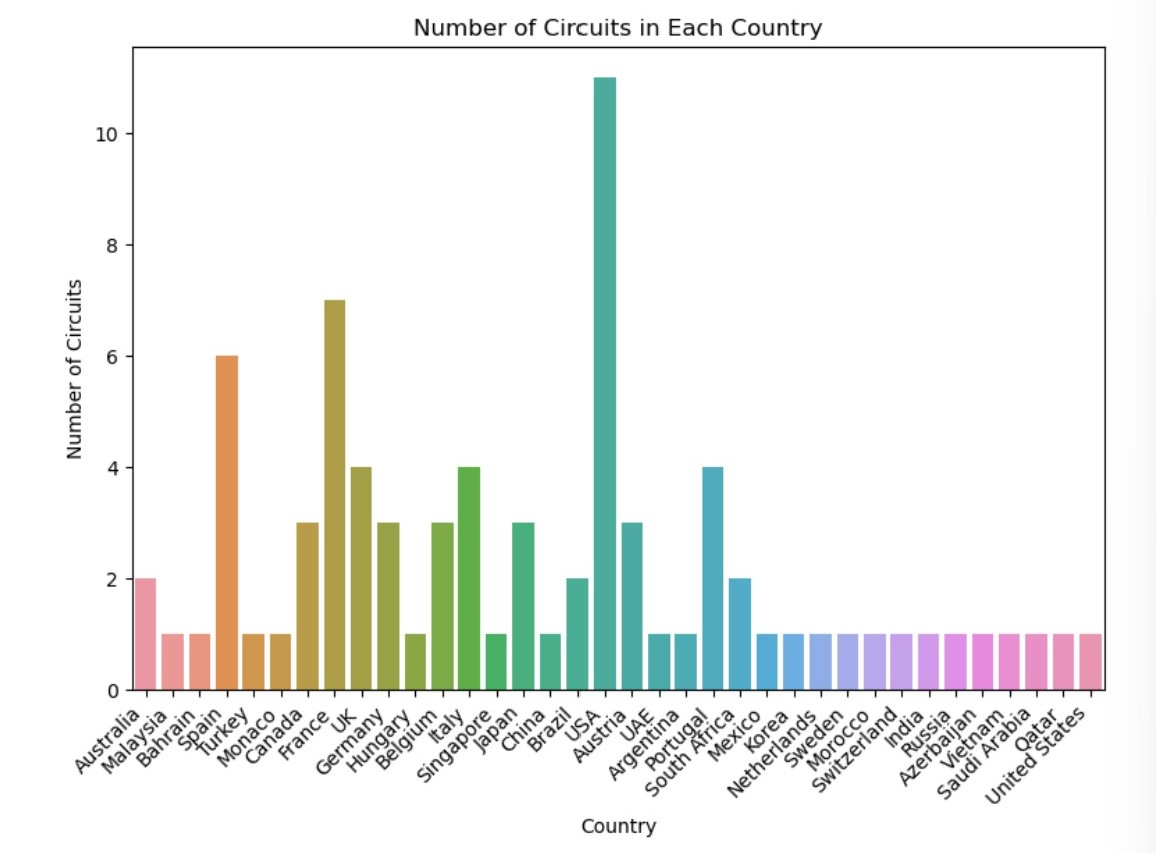

This first visual shows the number of circuits for each country this visual shows that the USA has the highest number of circuits followed by France and Spain.

##### Constructors Data

The constructor's dataset contains 5 columns and 211 entries. It contains information on the constructor Id, constructor reference, name, nationality, and url.

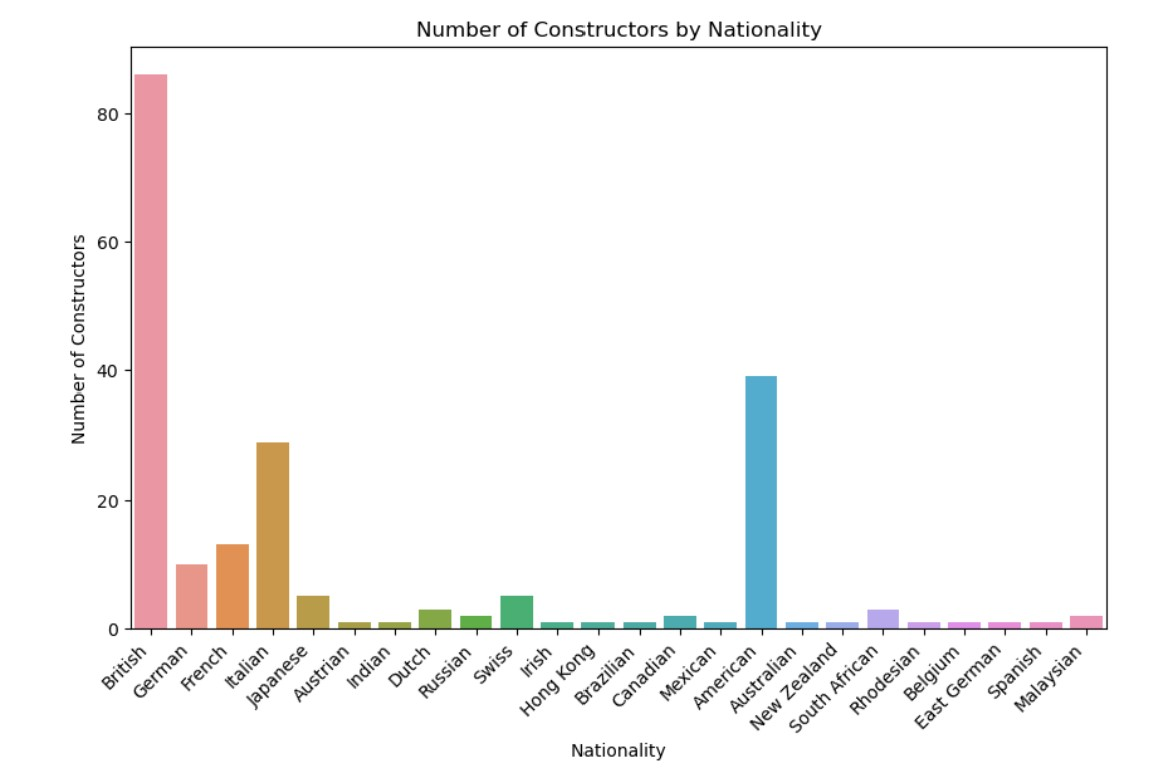

This visual shows the number of constructors by nationality. It shows that since 1950, the nationality with the most constructors is the British followed by Americans and the Italians.

###### Driver Standings Data

The driver standing dataset contains 7 columns and 33394 entries. It contains information on the driver standings Id, race Id, driver Id, points, position, position Text, and wins.

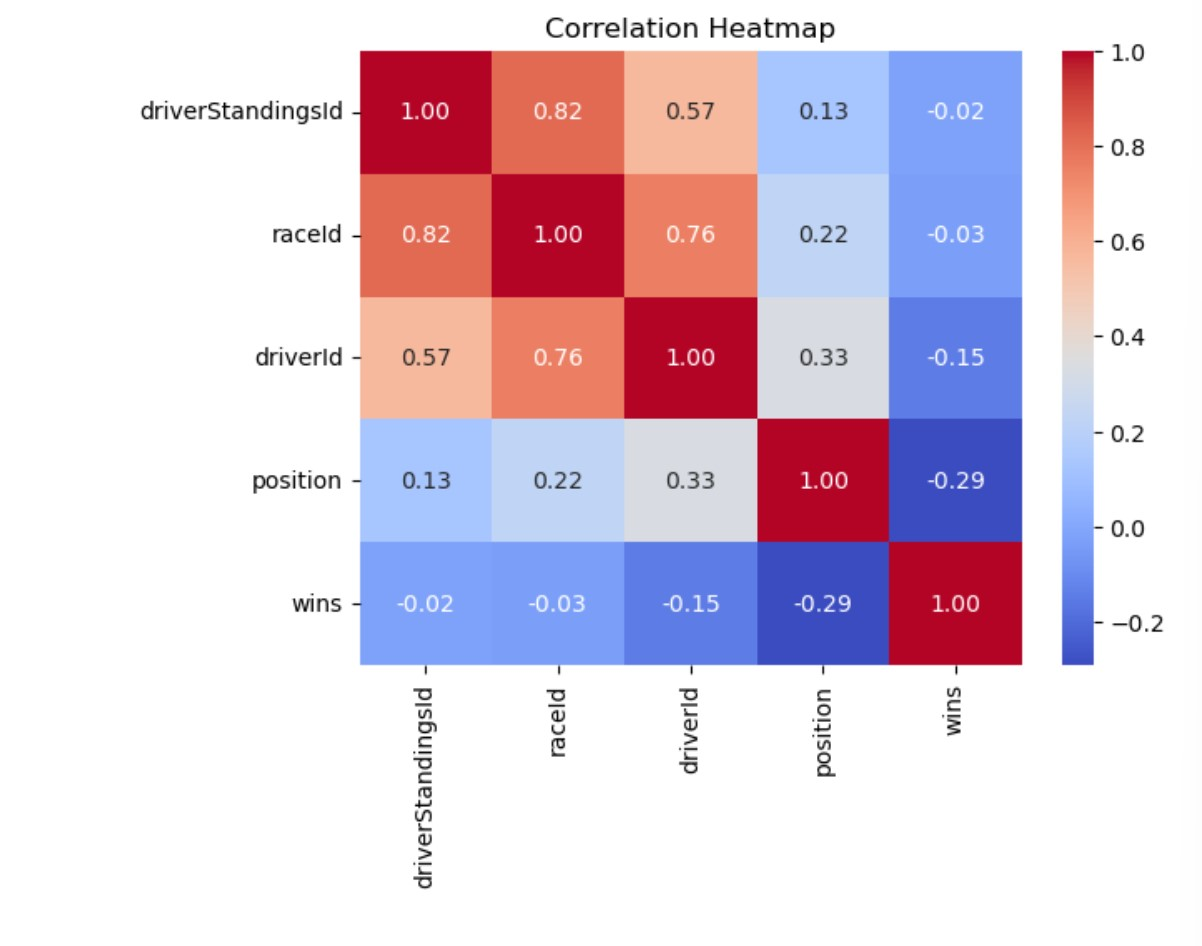

This visual shows a heatmap showing the correlation between the different numeric variables. This heatmap shows relationships between wins and driver id as well as wins and position. Through the shades of blue, it signifies an inverse relationship. For example, the higher the number of wins, the lower the position. It also shows a relationship between the driver Id and wins. 

###### Driver Data

The driver’s dataset contains 9 columns and 8854 entries. It contains information on driver Id, driver Reference, number, code, forename, surname, date of birth, nationality, and url.

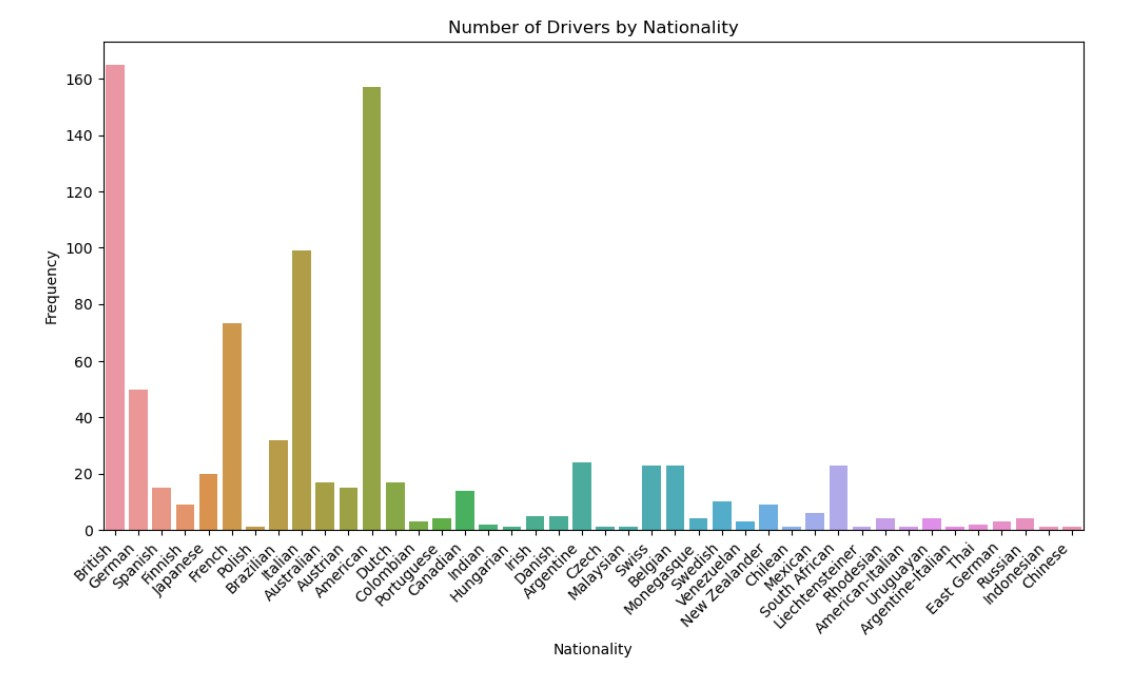

This visual shows the driver's nationality distribution. This visual shows that the majority of the drivers are British followed by Americans and Italians.

###### Race data

The race dataset contains 7 columns and 1080 entries. Containing information on race Id, round, circuit Id, name, date, time, and url.

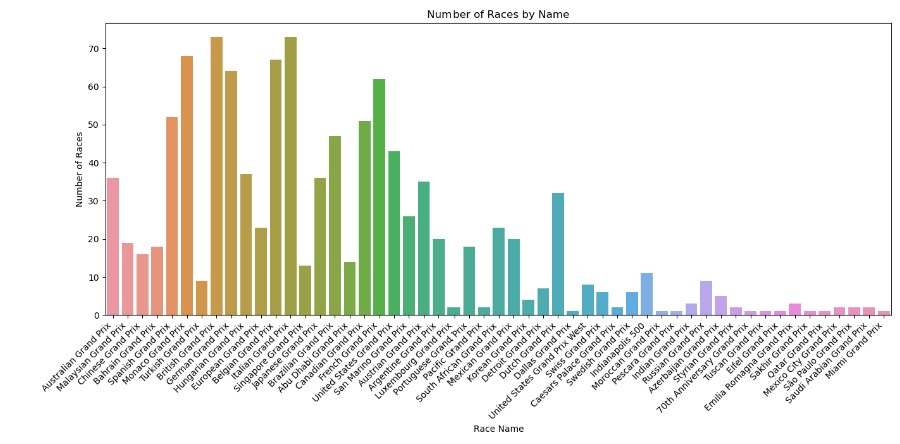

This visual shows the number of races held for each race since 1950. 

###### Results Data
The results dataset contains 18 columns with 25398 entries. It contains information on result Id, race Id, driver Id, constructor Id, number, grid, position, position Text, position Order, points laps, time, milliseconds, fastest lap, rank, fastest lap time, fastest lap speed, and status Id.

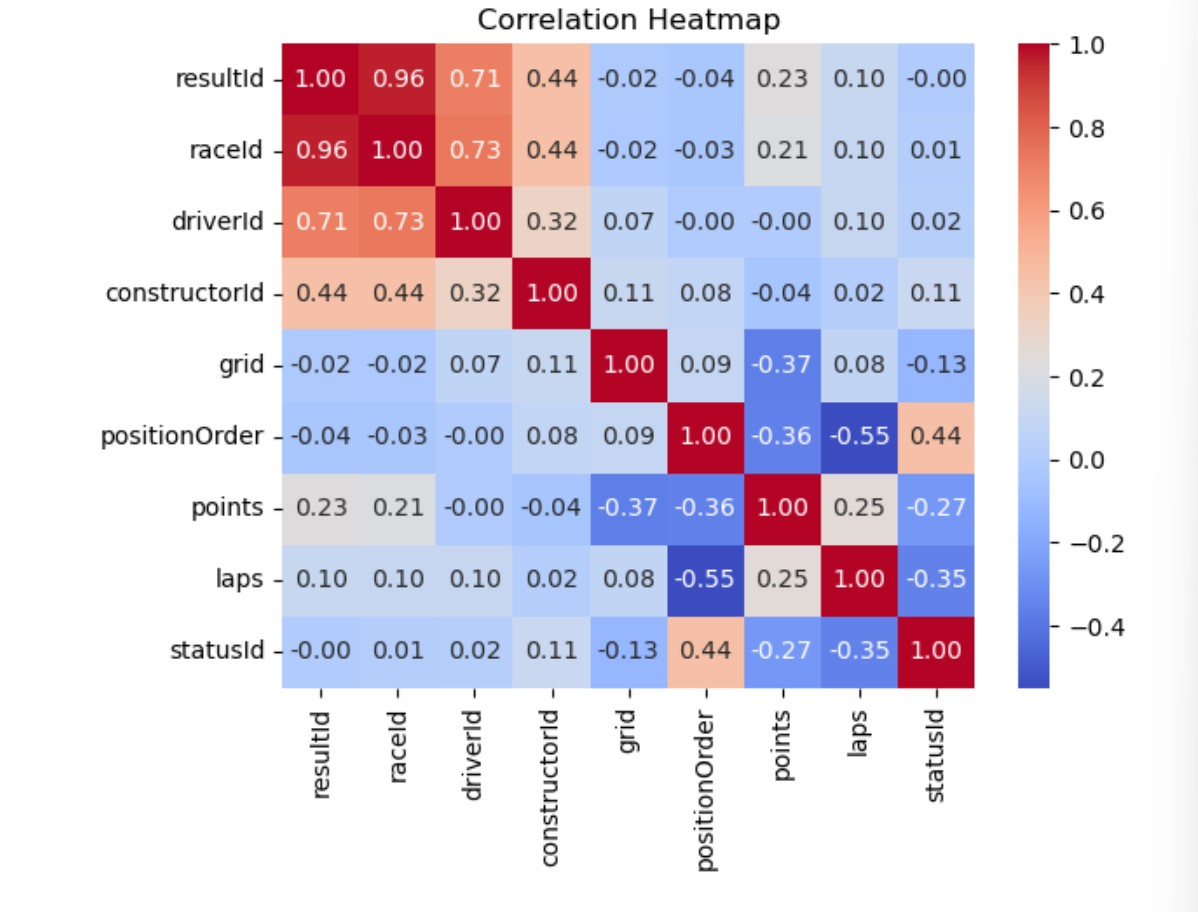

This visual shows a heatmap showing the correlation between the numerical variables of this dataset. This heatmap shows an inverse relationship between points and the grid showing that the lower the driver is on the grid, the higher their points.

After analyzing my data, I decided to construct a classification model to predict whether a driver would be in the top 10 drivers for each race. With this prediction, constructors will be able to make strategic insights, enhance Fan Engagement, and driver performance analysis.

## 3: Data Wrangling on multiple tables <a id="part2.3"></a>

Data wrangling on multiple tables, also known as data integration or data blending, involves the process of combining and transforming data from multiple sources or tables into a unified and structured format for analysis, visualization, and further processing. This is a crucial step in data preparation, as real-world data often resides in separate tables or databases, and it is essential to consolidate and clean this data before drawing insights. 

After loading and exploring the data sets, I now have a clearer understanding of the data within each dataset. With this information, I have chosen 6 tables to merge together to answer the prediction problem I have formulated, i.e. to predict the top 10 drivers for each race.

To create my tabular table, the datasets I have chosen are circuit data, constructors data, driver standings data, driver data, race data, and results data. With these tables, I aim to use the data within to create a table that can be used to make accurate predictions.

I first created a subset for each of my datasets containing the data in the columns to use from my circuits table. I chose the columns named ‘circuitId’, ‘country’, ‘name, and ‘alt’. From my constructor table, columns named ‘constructorId’, and ‘name’. From the driver standings table, columns named ‘raceId’, ‘driverId’, and ‘wins’. From the driver table, columns named ‘driverId’, ‘forename’, ‘surname’, and ‘dob. From the races table, columns named ‘raceId’, ‘circuitId’, ‘name’, and ‘date’. From the results table, columns named ‘raceId’, ‘driverId’, ‘constructorId’, ‘grid’, ‘positionOrder’, ‘fastestLapTime’, ‘fastestLapSpeed’, and ’laps’. After this, I renamed the column's names with repeated namings from the other subsets I have created. 

Next, I merged my subsets with one another using an inner join through their matching Ids. From this, I now have my created tabular table named merged_data which contains 19 columns and 24198 entries containing data on race Id, driver Id, constructor Id, grid, position Order, fastest lap time, fastest lap speed, laps, wins, forename, surname, dob, circuit Id, race name, date, country, circuit name, and alt.

With this tabular table created, I can now begin cleaning and transforming the dataset. 


## 4: Data Cleansing and Transformation <a id="part2.4"></a>

### Data Cleansing

Data cleansing is a fundamental step in the data preparation process that involves identifying and rectifying errors, inconsistencies, and inaccuracies in a dataset. Clean and accurate data is essential for making reliable and informed decisions, performing accurate analyses, and producing meaningful visualizations. 

####  Inconsistencies and data types
To clean the data in my table, I first fixed naming conventions and errors in the ‘country’ and ‘date’ columns as well as replacing any \N in the dataset with nan’s. Next, I handled the formatting and datatypes of my data, I did this for the column named ‘fastesLapTime’ converting its format (01:27.5) to milliseconds (1275). Next, I converted the column names ‘fastestlapspeed’ and ‘alt’ into a float types, column name ‘date’, and ‘dob’ into date times.

####  Null values
For my missing values, I filled them through interpolation using forward fill. For altitude I filled in the missing values with the alt mean average of their matching race Id’s altitude, and for the values with no matching race Id’s I used the mean for all the altitudes. Next for the missing values in fastest lap time and speed, I used the median of their matching race Ids speed and time and a general median for those values with no matching race Ids.

#### New features
Next, I created new features. The first feature I created is named top10. This column looks at my position order column and if the order is equal or less than 10 the value for the column would be a 1 and if not it will be a 0. This feature will be used as our target variable to calculate the top 10 drivers. Next, I created 4 new features the first is full name combining the driver's forename and last name together, next extracting the year and month from the date columns and lastly calculating the age of the drivers on the day of the race using the driver's dob and race date.

#### Text Preprocessing
Next, I did text preprocessing lowercasing, and removing spaces for my object columns. 

#### Checking for duplicates
After cleaning my data, I checked for any duplicates and had none. 

Finally, I dropped the columns Id’s named 'raceId', 'driverId', 'constructorId', 'positionOrder', 'circuitId', 'date', 'dob', 'forename', and 'surname'. 

### Data Transformation

#### Outliers
Next, I performed winzorisation on my outliers a process of limiting values to a certain threshold by replacing values above the high winsorization point with the upper limit value and values below a specified lower limit with the lower limit values. By replacing extreme values with less extreme but still observable values.

#### Power transformation
Yeo Johnson Transformer on my numerical data a process that generalizes both the Box-Cox transformation and the log transformation. It is used to stabilize variance and make data more approximately normally distributed. This transformation can be applied to positive and negative values and even to zero.

### Train Test Split
Next, I performed a train test split on my table with my target variable being the column named ‘top10’. 

### Encoding
#### Categorical
Now for encoding, I used one hot encoding for all my categorical data to convert my categorical variables into a binary matrix format. 

##### Numerical
Equal width discretion for all my numerical variables to convert continuous numerical data into discrete categories or intervals. The goal is to group similar data points into bins, where each bin represents a range of values. This can make the data more understandable and suitable for analysis

### Feature Engineering
For feature engineering, I performed robust scaling used to standardize numerical data by removing the median and scaling the data according to the interquartile range (IQR) and PCA to transform high-dimensional data into a lower-dimensional space while retaining as much of the original variability as possible to help reduce the impact of noise or less informative features on my train and test set. I also tried polynomial expansion but it lengthen my load time so I decided to not use it.

Now my train and test set is ready to be inputed into my machine learning model.


## 5: Machine Learning Modelling <a id="part2.5"></a>

Machine learning modeling is the process of building and training algorithms or models that can make predictions, classifications, or decisions based on input data.

For my naive baseline, I used a simple baseline model. The goal of this baseline model is to provide a point of reference to compare more complex models. Next, I created a logistic regression model a common method for binary classification tasks. 

With this implemented, I have established a Naive Baseline Model that predicts the most common class label for both training and test data and calculates its accuracy. Next, I created a Logistic Regression Model, to train it on the training set, to make predictions on both the X train and test sets, and calculate the accuracy for each. The comparison of the performance of the Naive Baseline Model with the Logistic Regression Model provides insights into the effectiveness of the logistic regression approach for the classification task. 

After running my Train test model, I have obtained the following results- a Naive Baseline Model's accuracy on the train data is 57.75%, a Naive Baseline Model's accuracy on the test data is 57.37%, a LogReg Model's accuracy on train data is 81.70% and a LogReg Model's accuracy on test data is 81.69%. The numbers and results presented provide insights into the performance of the Naive Baseline Model and the Logistic Regression Model. The accuracy scores give me an idea of how well each model is predicting the correct class labels on both the training and test data. The Logistic Regression Model shows significantly improved accuracy compared to the baseline model, suggesting its better predictive capabilities. 

The accuracy of my naive baseline model on my X_train is 57.75% meaning that the baseline model correctly predicts the class for approximately 57.75% of the training instances.

The accuracy of my naive baseline model on my X_test is 57.37% indicating that the baseline model's predictions are correct for approximately 57.37% of the test instances.

The accuracy of my Logistic Regression Model on my X_train is 81.70% indicating that the logistic regression model's predictions are correct for approximately 81.70% of the training instances. With my X_test having 34 columns and 17441 entries, this means that out of 17441 entries 14249 of them were accurate

The accuracy of my Logistic Regression Model on my X_test is 81.69% indicating that the logistic regression model's predictions are correct for approximately 81.69% of the training instances. With my X_test having 34 columns and 7476 entries this means that 6107 entries were accuartely predicted.

## 6: Summary & Further Improvement <a id="part2.6"></a>

### Summary

In this report, in order to create a predictive model to enhance strategic insights, fans’ engagement, and driver performance analysis on Formula 1 (F1), I created a predictive model using data from Ergast.com, to predict whether a driver will be among the top 10 in a race, benefiting Formula 1 teams, fans, and driver performance analysis.

To do so, I explored the datasets provided and created a tabular table with the relevant datasets. With this final table, I performed data cleaning and transforming on it, fixing up inconsistencies, formatting data types, filling in null values, adding new features doing text preprocessing, dropping columns dealing with outliers, and performing Yeo Johnson transformer.

After this, I split my table into a train and test set performing one hot encoding on my categorical variables and equal width discretion on my numerical variables preparing my train and test set for analysis, visualization, and machine learning tasks. For feature engineering, I used robust scaling and PCA on my train and test set to improve the performance of machine learning models.

Lastly, two  Machine Learning Models were employed a Naive Baseline Model and a Logistic Regression Model. The Naive Baseline Model predicted the most common class label and achieved an accuracy of around 57.75% on both training and test data. The Logistic Regression Model, a more sophisticated approach, attained accuracy rates of approximately 81.70% on training and 81.69% on test data, showcasing superior predictive performance compared to the baseline model.

### Further Improvements

Experiment with more encoding and discretion methods instead of using just one encoding and discretion method on my variables
Experiment with adding polynomial features, such as squared or cubed terms, can account for non-linear relationships that might exist in the data.
Use more tables to have a more complete dataset to gain deeper insights into the factors affecting the target variable.
